# Predicting war events

## I. Importing essential libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string

import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm.notebook import tqdm
from tqdm import tqdm
import pymorphy3

import os
from pathlib import Path
import json

## II. Importing datasets

In [2]:
df_weather = pd.read_csv("../data/all_weather_by_hour_2023-2025_v1.csv")

In [3]:
df_war_events_raw = pd.read_csv("../data/alarms-240222-010325.csv", sep=";")
df_regions = pd.read_csv("../data/regions.csv")

In [4]:
json_path_isw = Path("../data/isw_reports_v2.json")

with open(json_path_isw, "r", encoding="utf-8") as f:
    data = json.load(f)

df_isw_raw = pd.DataFrame(data)

print(type(df_isw_raw))

<class 'pandas.DataFrame'>


In [5]:
json_path_tg = Path("../data/telegram_data.json")

with open(json_path_tg, "r", encoding="utf-8") as f:
    data = json.load(f)

df_tg_raw = pd.DataFrame(data)

print(type(df_tg_raw))

<class 'pandas.DataFrame'>


## III. EDA

### Weather

In [6]:
pd.set_option("display.max_columns", None)
df_weather.head()

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations
0,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,00:00:00,1645653600,2.4,-1.6,89.18,0.8,0.0,0.0,0.1,0.2,['snow'],31.3,15.5,275.6,1020.0,0.0,91.5,0.0,NaN,0.0,Overcast,snow,obs,remote
1,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,01:00:00,1645657200,2.4,-1.5,87.90,0.6,0.0,0.0,0.0,0.2,['snow'],27.7,14.8,280.3,1021.0,0.2,88.2,0.0,NaN,0.0,Partially cloudy,fog,obs,remote
2,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,02:00:00,1645660800,2.9,-0.8,88.58,1.2,0.0,0.0,0.0,0.1,['snow'],29.2,14.4,310.0,1022.0,10.0,100.0,NaN,NaN,NaN,Overcast,cloudy,obs,33177099999
3,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,03:00:00,1645664400,2.3,-1.3,86.63,0.3,0.0,0.0,0.0,0.1,['snow'],23.8,13.3,295.1,1021.0,0.1,92.0,0.0,NaN,0.0,Overcast,fog,obs,remote
4,50.7469,25.3263,"Луцьк, Луцький район, Україна","Lutsk,Ukraine",Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,04:00:00,1645668000,1.9,-1.8,87.85,0.1,0.0,0.0,0.0,0.1,['snow'],24.5,13.3,305.8,1021.0,0.0,93.8,0.0,NaN,0.0,Overcast,cloudy,obs,remote


In [7]:
df_weather.tail()

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations
608299,49.5879,34.5517,"Полтава, Україна","Poltava,Ukraine",Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,19:00:00,1740848400,-1.3,-3.5,73.09,-5.5,0.0,0.0,0.0,2.0,NaN,11.5,5.8,174.9,1030.0,NaN,100.0,0.0,0.0,0.0,Overcast,cloudy,obs,remote
608300,49.5879,34.5517,"Полтава, Україна","Poltava,Ukraine",Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,20:00:00,1740852000,-1.8,-1.8,81.17,-4.6,0.0,0.0,0.0,2.0,NaN,13.0,0.0,170.5,1029.6,10.0,100.0,0.0,0.0,0.0,Overcast,cloudy,obs,33506099999
608301,49.5879,34.5517,"Полтава, Україна","Poltava,Ukraine",Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,21:00:00,1740855600,-1.0,-3.5,68.31,-6.1,0.0,0.0,0.0,2.0,NaN,11.9,6.8,168.7,1029.0,NaN,99.6,0.0,0.0,0.0,Overcast,cloudy,obs,remote
608302,49.5879,34.5517,"Полтава, Україна","Poltava,Ukraine",Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,22:00:00,1740859200,-1.7,-4.5,71.36,-6.2,0.0,0.0,0.0,2.0,NaN,12.6,7.2,173.4,1029.0,NaN,98.2,0.0,0.0,0.0,Overcast,cloudy,obs,remote
608303,49.5879,34.5517,"Полтава, Україна","Poltava,Ukraine",Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,23:00:00,1740862800,-2.1,-2.1,84.88,-4.3,0.0,0.0,0.0,2.0,NaN,13.0,0.0,182.0,1028.6,10.0,100.0,0.0,0.0,0.0,Overcast,cloudy,obs,33506099999


In [8]:
rows, columns = df_weather.shape
print(f'Rows: {rows}, columns: {columns}')

Rows: 608304, columns: 65


In [9]:
df_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 608304 entries, 0 to 608303
Data columns (total 65 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   city_latitude         608304 non-null  float64
 1   city_longitude        608304 non-null  float64
 2   city_resolvedAddress  608304 non-null  str    
 3   city_address          608304 non-null  str    
 4   city_timezone         608304 non-null  str    
 5   city_tzoffset         608304 non-null  float64
 6   day_datetime          608304 non-null  str    
 7   day_datetimeEpoch     608304 non-null  int64  
 8   day_tempmax           608304 non-null  float64
 9   day_tempmin           608304 non-null  float64
 10  day_temp              608304 non-null  float64
 11  day_feelslikemax      608304 non-null  float64
 12  day_feelslikemin      608304 non-null  float64
 13  day_feelslike         608304 non-null  float64
 14  day_dew               608304 non-null  float64
 15  day_humidit

In [10]:
df_weather.describe()

,city_latitude,city_longitude,city_tzoffset,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunriseEpoch,day_sunsetEpoch,day_moonphase,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex
count,608304.000000,608304.000000,608304.0,6.083040e+05,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,552952.000000,607752.000000,607752.000000,607752.000000,6.083040e+05,6.083040e+05,608304.000000,6.083040e+05,608304.000000,608304.000000,608304.000000,608304.000000,608202.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.000000,608304.00000,331846.000000,608304.000000,603968.000000,521042.000000,603968.000000
mean,49.143238,30.142514,2.0,1.693217e+09,15.203232,6.253993,10.721077,14.287248,4.267318,9.254504,5.285646,72.891185,2.095628,53.533924,6.553061,0.121132,0.598356,34.879037,18.545700,191.158465,1016.920939,64.812537,14.917199,141.953237,12.242466,4.806077,1.693240e+09,1.693284e+09,0.489195,1.693258e+09,10.719390,9.252908,72.891267,5.283823,0.087357,6.552809,0.005045,0.598141,23.769943,11.399938,189.830264,1016.91840,17.010448,64.811065,142.722294,0.595017,1.413903
std,1.337209,4.303973,0.0,2.748558e+07,10.592473,8.162055,9.207622,11.577354,9.929590,10.713666,7.473743,14.564090,10.685616,49.874998,12.103297,0.662849,1.998581,11.736481,6.887631,106.201073,8.446172,28.824705,7.753173,96.845076,8.371915,2.653499,2.748640e+07,2.748407e+07,0.289963,2.748559e+07,9.787529,11.293806,19.456422,7.652857,2.141735,24.745557,0.048299,2.615546,11.492758,6.517607,106.383976,8.68127,9.656796,37.318628,220.920973,0.828064,2.226545
min,46.472500,22.285100,2.0,1.645654e+09,-14.300000,-50.300000,-17.500000,-21.800000,-50.300000,-27.100000,-20.700000,23.300000,0.000000,0.000000,0.000000,0.000000,0.000000,6.100000,2.500000,0.000000,981.600000,0.000000,0.000000,0.000000,0.000000,0.000000,1.645676e+09,1.645715e+09,0.000000,1.645654e+09,-50.300000,-50.300000,8.460000,-25.900000,0.000000,0.000000,0.000000,0.000000,0.700000,0.000000,0.000000,973.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.292400,25.935500,2.0,1.669414e+09,5.900000,-0.200000,2.800000,3.800000,-3.800000,-0.100000,-0.300000,62.400000,0.000000,0.000000,0.000000,0.000000,0.000000,26.600000,14.000000,98.200000,1011.500000,43.900000,9.900000,51.200000,4.400000,2.000000,1.669441e+09,1.669472e+09,0.250000,1.669456e+09,2.400000,-0.300000,59.310000,-0.400000,0.000000,0.000000,0.000000,0.000000,14.800000,7.200000,98.000000,1011.20000,10.000000,30.000000,0.000000,0.000000,0.000000
50%,49.416800,30.737100,2.0,1.693256e+09,15.100000,6.100000,10.600000,15.100000,4.200000,9.900000,5.300000,74.200000,0.100000,100.000000,4.170000,0.000000,0.000000,33.800000,18.000000,195.600000,1016.500000,70.700000,12.500000,129.400000,11.200000,5.000000,1.693277e+09,1.693326e+09,0.500000,1.693258e+09,10.200000,10.200000,77.430000,5.300000,0.000000,0.000000,0.000000,0.000000,22.300000,10.800000,191.900000,1016.60000,15.800000,80.000000,5.600000,0.100000,0.000000
75%,50.253600,34.551700,2.0,1.717016e+09,24.600000,13.200000,18.800000,24.600000,13.200000,18.800000,11.500000,84.800000,1.092000,100.000000,8.330000,0.000000,0.000000,41.400000,22.000000,287.000000,1022.000000,90.600000,20.000000,226.800000,19.600000,7.000000,1.717035e+09,1.717092e+09,0.750000,1.717060e+09,18.400000,18.400000,89.050000,11.500000,0.000000,0.

In [11]:
df_weather.isna().sum()

city_latitude              0
city_longitude             0
city_resolvedAddress       0
city_address               0
city_timezone              0
                        ... 
hour_uvindex            4336
hour_conditions            0
hour_icon                  0
hour_source                0
hour_stations              0
Length: 65, dtype: int64

In [12]:
categorical_cols = ['city_resolvedAddress', 'city_address', 'city_timezone', 'day_conditions', 'day_description',
                    'day_icon', 'day_preciptype', 'hour_preciptype', 'hour_conditions', 'hour_icon', 'day_source',
                    'hour_source', 'day_stations', 'hour_stations']
numeric_cols = ['day_tempmax', 'day_tempmin', 'day_temp', 'hour_temp', 'day_feelslike', 'day_feelslikemax',
                'day_feelslikemin', 'hour_feelslike', 'day_humidity', 'hour_humidity', 'day_dew', 'hour_dew',
                'day_precip', 'day_precipprob', 'day_precipcover', 'hour_precip', 'hour_precipprob',
                'day_snow', 'day_snowdepth', 'hour_snow', 'hour_snowdepth', 'day_windgust', 'day_windspeed',
                'day_winddir', 'hour_windgust', 'hour_windspeed', 'hour_winddir', 'day_pressure', 'hour_pressure',
                'day_cloudcover', 'hour_cloudcover','day_visibility', 'hour_visibility', 'day_solarradiation',
                'day_solarenergy', 'day_uvindex', 'hour_solarradiation', 'hour_solarenergy','hour_uvindex',
                'city_latitude', 'city_longitude', 'city_tzoffset', 'day_moonphase']
time_cols = ['day_datetime', 'day_datetimeEpoch', 'hour_datetime', 'hour_datetimeEpoch',
             'day_sunrise', 'day_sunriseEpoch', 'day_sunset', 'day_sunsetEpoch']

print("Categorical columns:", categorical_cols)
print("\nNumeric columns:", numeric_cols)
print("\nTime columns:", time_cols)

Categorical columns: ['city_resolvedAddress', 'city_address', 'city_timezone', 'day_conditions', 'day_description', 'day_icon', 'day_preciptype', 'hour_preciptype', 'hour_conditions', 'hour_icon', 'day_source', 'hour_source', 'day_stations', 'hour_stations']

Numeric columns: ['day_tempmax', 'day_tempmin', 'day_temp', 'hour_temp', 'day_feelslike', 'day_feelslikemax', 'day_feelslikemin', 'hour_feelslike', 'day_humidity', 'hour_humidity', 'day_dew', 'hour_dew', 'day_precip', 'day_precipprob', 'day_precipcover', 'hour_precip', 'hour_precipprob', 'day_snow', 'day_snowdepth', 'hour_snow', 'hour_snowdepth', 'day_windgust', 'day_windspeed', 'day_winddir', 'hour_windgust', 'hour_windspeed', 'hour_winddir', 'day_pressure', 'hour_pressure', 'day_cloudcover', 'hour_cloudcover', 'day_visibility', 'hour_visibility', 'day_solarradiation', 'day_solarenergy', 'day_uvindex', 'hour_solarradiation', 'hour_solarenergy', 'hour_uvindex', 'city_latitude', 'city_longitude', 'city_tzoffset', 'day_moonphase']



In [13]:
df_weather['city_address'].value_counts()

city_address
Lutsk,Ukraine              26448
Kropyvnytskyi,Ukraine      26448
Dnipro,Ukraine             26448
Kyiv,Ukraine               26448
Kherson,Ukraine            26448
Chernivtsi,Ukraine         26448
Chernihiv,Ukraine          26448
Odesa,Ukraine              26448
Mykolaiv,Ukraine           26448
Kharkiv,Ukraine            26448
Khmelnytskyi,Ukraine       26448
Donetsk,Ukraine            26448
Uzhgorod,Ukraine           26448
Zaporozhye,Ukraine         26448
Rivne,Ukraine              26448
Zhytomyr,Ukraine           26448
Ternopil,Ukraine           26448
Poltava,Ukraine            26448
Lviv,Ukraine               26448
Ivano-Frankivsk,Ukraine    26448
Cherkasy,Ukraine           26448
Sumy,Ukraine               26448
Vinnytsia,Ukraine          26448
Name: count, dtype: int64

In [14]:
df_weather['city_timezone'].value_counts()

city_timezone
Europe/Kiev          555408
Europe/Uzhgorod       26448
Europe/Zaporozhye     26448
Name: count, dtype: int64

In [15]:
df_weather['city_resolvedAddress'].value_counts()

city_resolvedAddress
Луцьк, Луцький район, Україна           26448
Кропивницький, Україна                  26448
Дніпро, Україна                         26448
Київ, Україна                           26448
Херсон, Україна                         26448
Чернівці, Україна                       26448
Чернігів, Україна                       26448
Одеса, Україна                          26448
Миколаїв, Україна                       26448
Харків, Україна                         26448
Хмельницька область, Україна            26448
Донецьк, Україна                        26448
Ужгород, Ужгородський район, Україна    26448
Запоріжжя, Україна                      26448
Рівне, Україна                          26448
Житомир, Україна                        26448
Тернопіль, Україна                      26448
Полтава, Україна                        26448
Львів, Україна                          26448
Івано-Франківськ, Україна               26448
Черкаси, Україна                        26448
Суми, Україна

In [16]:
df_weather['hour_stations'].value_counts()

hour_stations
remote                                                  403732
UUOB                                                     20591
33902099999                                              12452
15023099999;15007099999;LRSV;15000099999                 12418
33837099999                                               7528
                                                         ...  
11968099999;11993099999;LZKZ                                 1
11968099999;LZKZ                                             1
11993099999;11978099999;11927199999;LZKZ                     1
11933099999;11978099999;11927199999;33631099999;LZKZ         1
11968099999;11933099999;33631099999                          1
Name: count, Length: 154, dtype: int64

In [17]:
df_weather.duplicated().sum()

np.int64(0)

In [18]:
df_weather['day_datetime'].head()

0    2022-02-24
1    2022-02-24
2    2022-02-24
3    2022-02-24
4    2022-02-24
Name: day_datetime, dtype: str

Preprocessing

In [19]:
df_weather["city_address"] = df_weather["city_address"].str.replace(",Ukraine", "")

In [20]:
df_weather["city_address"].unique()

<StringArray>
[          'Lutsk',   'Kropyvnytskyi',          'Dnipro',            'Kyiv',
         'Kherson',      'Chernivtsi',       'Chernihiv',           'Odesa',
        'Mykolaiv',         'Kharkiv',    'Khmelnytskyi',         'Donetsk',
        'Uzhgorod',      'Zaporozhye',           'Rivne',        'Zhytomyr',
        'Ternopil',         'Poltava',            'Lviv', 'Ivano-Frankivsk',
        'Cherkasy',            'Sumy',       'Vinnytsia']
Length: 23, dtype: str

The dataset does not contain data for the following cities: Luhansk, Simferopol

In [21]:
df_weather['day_datetime'] = pd.to_datetime(df_weather['day_datetime'], errors="coerce")

In [22]:
df_weather["datetime_hour"] = (
    df_weather["day_datetime"] +
    pd.to_timedelta(df_weather["hour_datetime"].astype(str))
)

df_weather["year"] = df_weather["day_datetime"].dt.year
df_weather["month"] = df_weather["day_datetime"].dt.month
df_weather["day_of_week"] = df_weather["day_datetime"].dt.dayofweek

df_weather["hour"] = df_weather["hour_datetime"].str.split(":").str[0].astype(int)

In [23]:
df_weather["hour"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

In [24]:
df_weather.head()

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations,datetime_hour,year,month,day_of_week,hour
0,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,00:00:00,1645653600,2.4,-1.6,89.18,0.8,0.0,0.0,0.1,0.2,['snow'],31.3,15.5,275.6,1020.0,0.0,91.5,0.0,NaN,0.0,Overcast,snow,obs,remote,2022-02-24 00:00:00,2022,2,3,0
1,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,01:00:00,1645657200,2.4,-1.5,87.90,0.6,0.0,0.0,0.0,0.2,['snow'],27.7,14.8,280.3,1021.0,0.2,88.2,0.0,NaN,0.0,Partially cloudy,fog,obs,remote,2022-02-24 01:00:00,2022,2,3,1
2,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,02:00:00,1645660800,2.9,-0.8,88.58,1.2,0.0,0.0,0.0,0.1,['snow'],29.2,14.4,310.0,1022.0,10.0,100.0,NaN,NaN,NaN,Overcast,cloudy,obs,33177099999,2022-02-24 02:00:00,2022,2,3,2
3,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,03:00:00,1645664400,2.3,-1.3,86.63,0.3,0.0,0.0,0.0,0.1,['snow'],23.8,13.3,295.1,1021.0,0.1,92.0,0.0,NaN,0.0,Overcast,fog,obs,remote,2022-02-24 03:00:00,2022,2,3,3
4,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,04:00:00,1645668000,1.9,-1.8,87.85,0.1,0.0,0.0,0.0,0.1,['snow'],24.5,13.3,305.8,1021.0,0.0,93.8,0.0,NaN,0.0,Overcast,cloudy,obs,remote,2022-02-24 04:00:00,2022,2,3,4


In [25]:
df_weather['day_solarradiation'] = df_weather['day_solarradiation'].fillna(df_weather['day_solarradiation'].median())
df_weather['day_solarenergy'] = df_weather['day_solarenergy'].fillna(df_weather['day_solarenergy'].median())
df_weather['day_uvindex'] = df_weather['day_uvindex'].fillna(df_weather['day_uvindex'].median())

df_weather['hour_solarradiation'] = df_weather['hour_solarradiation'].fillna(df_weather['hour_solarradiation'].median())
df_weather['hour_solarenergy'] = df_weather['hour_solarenergy'].fillna(df_weather['hour_solarenergy'].median())
df_weather['hour_uvindex'] = df_weather['hour_uvindex'].fillna(df_weather['hour_uvindex'].median())

df_weather['hour_precip'] = df_weather['hour_precip'].fillna(0)

In [26]:
df_weather.head()

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations,datetime_hour,year,month,day_of_week,hour
0,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,00:00:00,1645653600,2.4,-1.6,89.18,0.8,0.0,0.0,0.1,0.2,['snow'],31.3,15.5,275.6,1020.0,0.0,91.5,0.0,0.1,0.0,Overcast,snow,obs,remote,2022-02-24 00:00:00,2022,2,3,0
1,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,01:00:00,1645657200,2.4,-1.5,87.90,0.6,0.0,0.0,0.0,0.2,['snow'],27.7,14.8,280.3,1021.0,0.2,88.2,0.0,0.1,0.0,Partially cloudy,fog,obs,remote,2022-02-24 01:00:00,2022,2,3,1
2,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,02:00:00,1645660800,2.9,-0.8,88.58,1.2,0.0,0.0,0.0,0.1,['snow'],29.2,14.4,310.0,1022.0,10.0,100.0,5.6,0.1,0.0,Overcast,cloudy,obs,33177099999,2022-02-24 02:00:00,2022,2,3,2
3,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,03:00:00,1645664400,2.3,-1.3,86.63,0.3,0.0,0.0,0.0,0.1,['snow'],23.8,13.3,295.1,1021.0,0.1,92.0,0.0,0.1,0.0,Overcast,fog,obs,remote,2022-02-24 03:00:00,2022,2,3,3
4,50.7469,25.3263,"Луцьк, Луцький район, Україна",Lutsk,Europe/Kiev,2.0,2022-02-24,1645653600,4.9,0.7,2.6,4.0,-3.1,-0.2,0.0,83.7,0.118,100.0,4.17,0.1,0.1,32.4,15.5,252.7,1022.3,72.3,12.2,36.9,2.8,1.0,07:13:36,1645679616,17:51:06,1645717866,0.77,"Snow, Partially cloudy",Partly cloudy throughout the day with morning ...,snow,obs,snow,33177099999;UKLR;remote;33301099999,04:00:00,1645668000,1.9,-1.8,87.85,0.1,0.0,0.0,0.0,0.1,['snow'],24.5,13.3,305.8,1021.0,0.0,93.8,0.0,0.1,0.0,Overcast,cloudy,obs,remote,2022-02-24 04:00:00,2022,2,3,4


In [27]:
df_weather.tail()

,city_latitude,city_longitude,city_resolvedAddress,city_address,city_timezone,city_tzoffset,day_datetime,day_datetimeEpoch,day_tempmax,day_tempmin,day_temp,day_feelslikemax,day_feelslikemin,day_feelslike,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,day_snow,day_snowdepth,day_windgust,day_windspeed,day_winddir,day_pressure,day_cloudcover,day_visibility,day_solarradiation,day_solarenergy,day_uvindex,day_sunrise,day_sunriseEpoch,day_sunset,day_sunsetEpoch,day_moonphase,day_conditions,day_description,day_icon,day_source,day_preciptype,day_stations,hour_datetime,hour_datetimeEpoch,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_snow,hour_snowdepth,hour_preciptype,hour_windgust,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_solarradiation,hour_solarenergy,hour_uvindex,hour_conditions,hour_icon,hour_source,hour_stations,datetime_hour,year,month,day_of_week,hour
608299,49.5879,34.5517,"Полтава, Україна",Poltava,Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,19:00:00,1740848400,-1.3,-3.5,73.09,-5.5,0.0,0.0,0.0,2.0,NaN,11.5,5.8,174.9,1030.0,NaN,100.0,0.0,0.0,0.0,Overcast,cloudy,obs,remote,2025-03-01 19:00:00,2025,3,5,19
608300,49.5879,34.5517,"Полтава, Україна",Poltava,Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,20:00:00,1740852000,-1.8,-1.8,81.17,-4.6,0.0,0.0,0.0,2.0,NaN,13.0,0.0,170.5,1029.6,10.0,100.0,0.0,0.0,0.0,Overcast,cloudy,obs,33506099999,2025-03-01 20:00:00,2025,3,5,20
608301,49.5879,34.5517,"Полтава, Україна",Poltava,Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,21:00:00,1740855600,-1.0,-3.5,68.31,-6.1,0.0,0.0,0.0,2.0,NaN,11.9,6.8,168.7,1029.0,NaN,99.6,0.0,0.0,0.0,Overcast,cloudy,obs,remote,2025-03-01 21:00:00,2025,3,5,21
608302,49.5879,34.5517,"Полтава, Україна",Poltava,Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,22:00:00,1740859200,-1.7,-4.5,71.36,-6.2,0.0,0.0,0.0,2.0,NaN,12.6,7.2,173.4,1029.0,NaN,98.2,0.0,0.0,0.0,Overcast,cloudy,obs,remote,2025-03-01 22:00:00,2025,3,5,22
608303,49.5879,34.5517,"Полтава, Україна",Poltava,Europe/Kiev,2.0,2025-03-01,1740780000,0.3,-6.9,-3.0,-1.1,-10.3,-5.5,-5.9,81.2,0.0,0.0,0.0,0.0,2.0,26.6,12.2,164.8,1030.4,91.1,7.0,106.1,9.2,4.0,06:24:29,1740803069,17:24:37,1740842677,0.05,Overcast,Cloudy skies throughout the day.,cloudy,obs,NaN,remote;33506099999,23:00:00,1740862800,-2.1,-2.1,84.88,-4.3,0.0,0.0,0.0,2.0,NaN,13.0,0.0,182.0,1028.6,10.0,100.0,0.0,0.0,0.0,Overcast,cloudy,obs,33506099999,2025-03-01 23:00:00,2025,3,5,23


In [28]:
def simplify_weather(x):
    if 'Snow' in x:
        return 'Snow'
    if 'Rain' in x:
        return 'Rain'
    if 'Overcast' in x or 'cloudy' in x:
        return 'Cloudy'
    if 'Clear' in x:
        return 'Clear'
    if 'Fog' in x:
        return 'Fog'
    return 'Other'

df_weather['hour_conditions_simple'] = df_weather['hour_conditions'].apply(simplify_weather)
df_weather['day_conditions_simple'] = df_weather['day_conditions'].apply(simplify_weather)

In [29]:
df_weather = pd.get_dummies(df_weather, columns=['day_conditions_simple','hour_conditions_simple'])

In [30]:
df_weather[['day_conditions','hour_conditions']].nunique()

day_conditions     19
hour_conditions    16
dtype: int64

Deleting the columns

In [31]:
df_weather = df_weather.drop(columns=[
    "city_resolvedAddress",
    "day_stations",
    "day_source",
    "hour_source",
    "hour_icon",
    "hour_stations",
    "hour_datetimeEpoch",
    'hour_preciptype',
    "hour_visibility",
    "day_visibility",
    'day_preciptype',
    "day_icon",
    "day_description",
    "day_datetimeEpoch",
    "day_sunriseEpoch",
    "day_sunsetEpoch"
])

In [32]:
df_weather = df_weather.drop(columns=['hour_conditions', 'day_conditions'])

In [33]:
df_weather.isna().sum()

city_latitude                    0
city_longitude                   0
city_address                     0
city_timezone                    0
city_tzoffset                    0
day_datetime                     0
day_tempmax                      0
day_tempmin                      0
day_temp                         0
day_feelslikemax                 0
day_feelslikemin                 0
day_feelslike                    0
day_dew                          0
day_humidity                     0
day_precip                       0
day_precipprob                   0
day_precipcover                  0
day_snow                         0
day_snowdepth                    0
day_windgust                     0
day_windspeed                    0
day_winddir                      0
day_pressure                     0
day_cloudcover                   0
day_solarradiation               0
day_solarenergy                  0
day_uvindex                      0
day_sunrise                      0
day_sunset          

Visualization

In [34]:
corr = df_weather.corr(numeric_only=True)

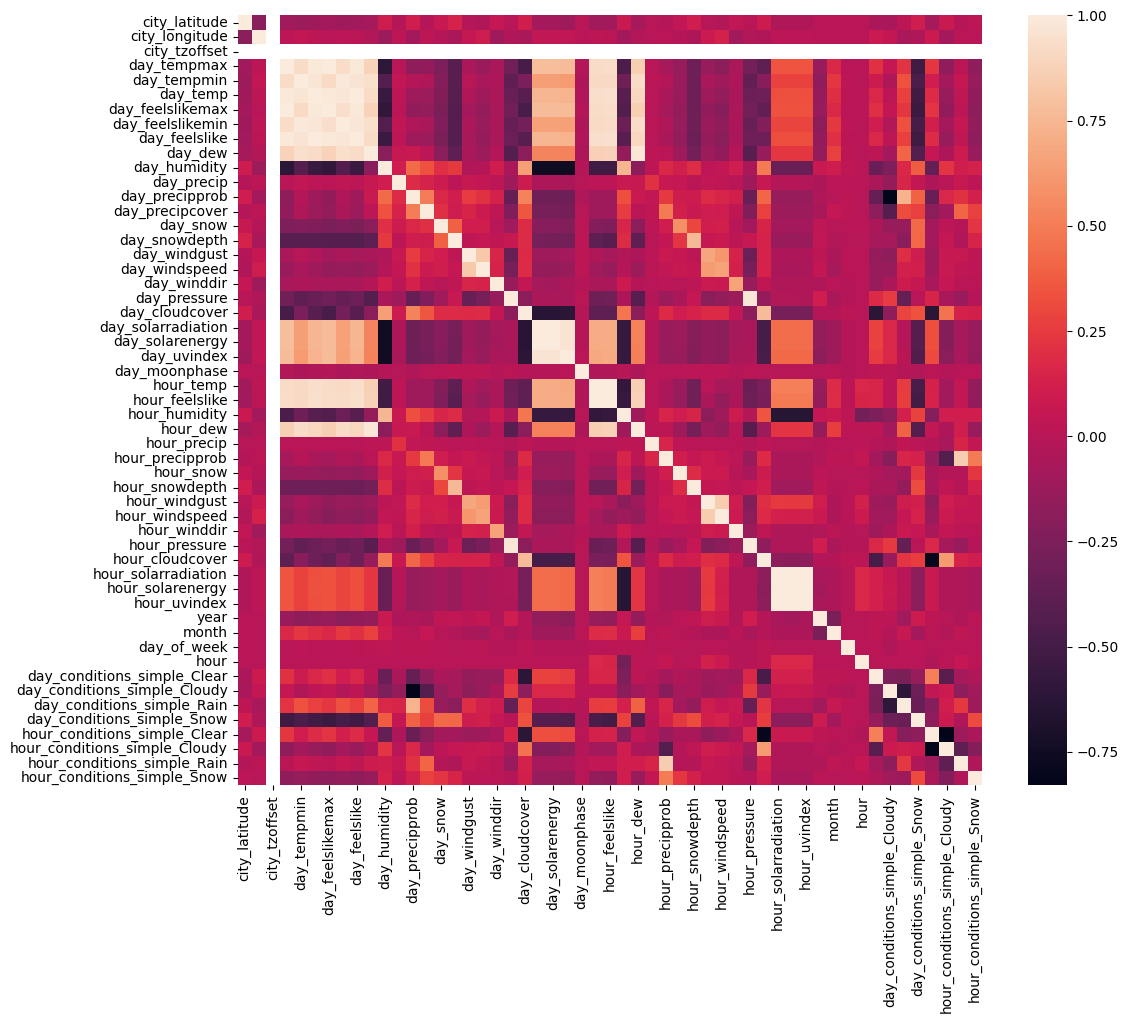

In [35]:
plt.figure(figsize=(12,10))
sns.heatmap(corr)
plt.show()

Correlation analysis was performed for all numeric weather variables. Strong correlations were observed between temperature and feels-like temperature, as well as between humidity and dew point, which is expected due to their physical relationship.

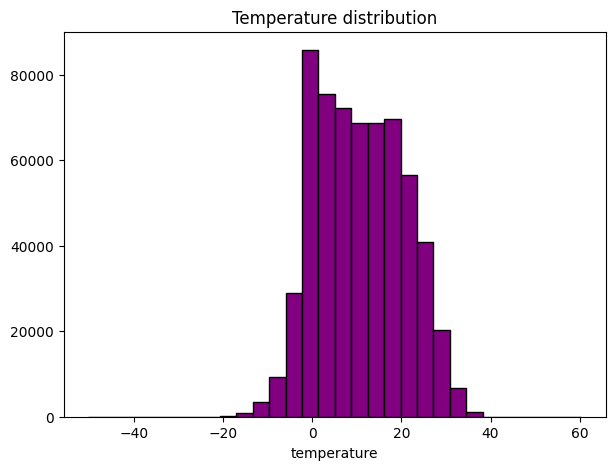

In [36]:
plt.figure(figsize=(7, 5))
plt.hist(df_weather['hour_temp'], bins=30, color='purple', edgecolor='black')
plt.title('Temperature distribution')
plt.xlabel('temperature')
plt.show()

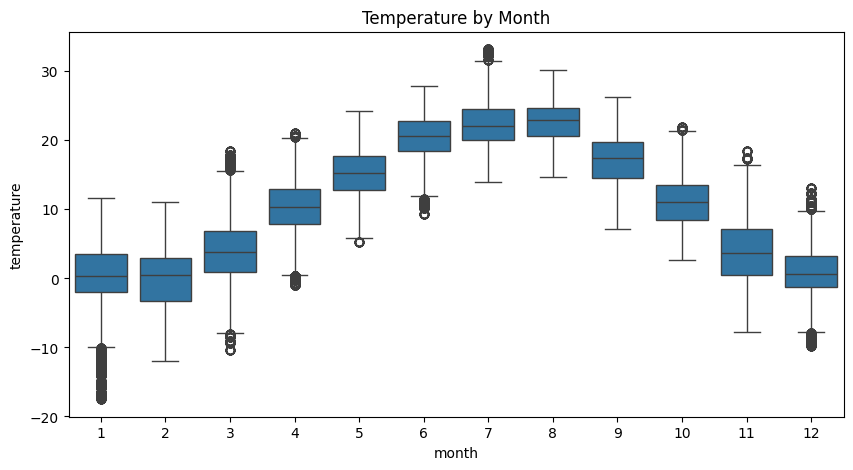

In [37]:
plt.figure(figsize=(10,5))
sns.boxplot(x="month", y="day_temp", data=df_weather)
plt.title("Temperature by Month")
plt.ylabel('temperature')
plt.show()

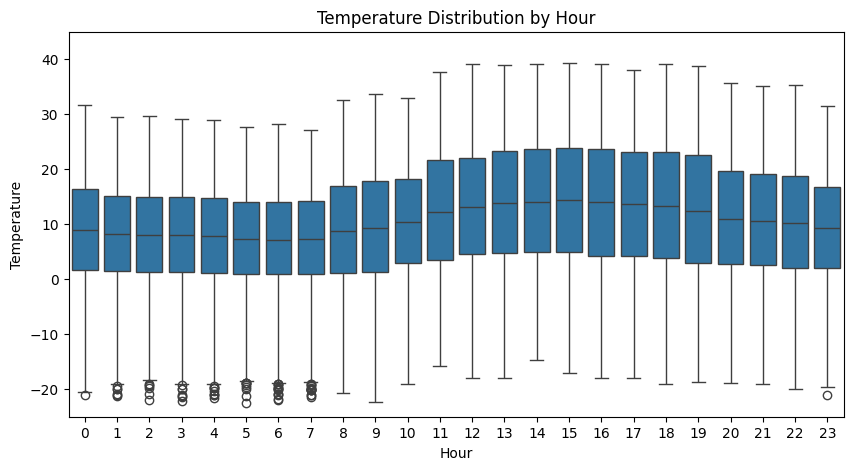

In [38]:
plt.figure(figsize=(10,5))

sns.boxplot(x="hour", y="hour_temp", data=df_weather)

plt.title("Temperature Distribution by Hour")
plt.xlabel("Hour")
plt.ylabel("Temperature")

plt.xticks(range(24))
plt.ylim(-25, 45)
plt.show()

Text(0.5, 0, 'Temperature')

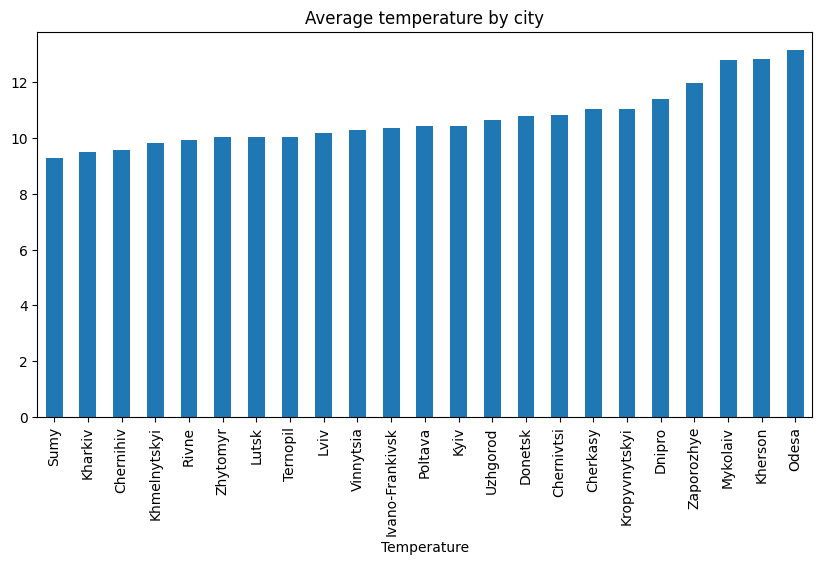

In [39]:
plt.figure(figsize=(10,5))
df_weather.groupby("city_address")["hour_temp"].mean().sort_values().plot(kind="bar")
plt.title("Average temperature by city")
plt.xlabel('Cities')
plt.xlabel('Temperature')

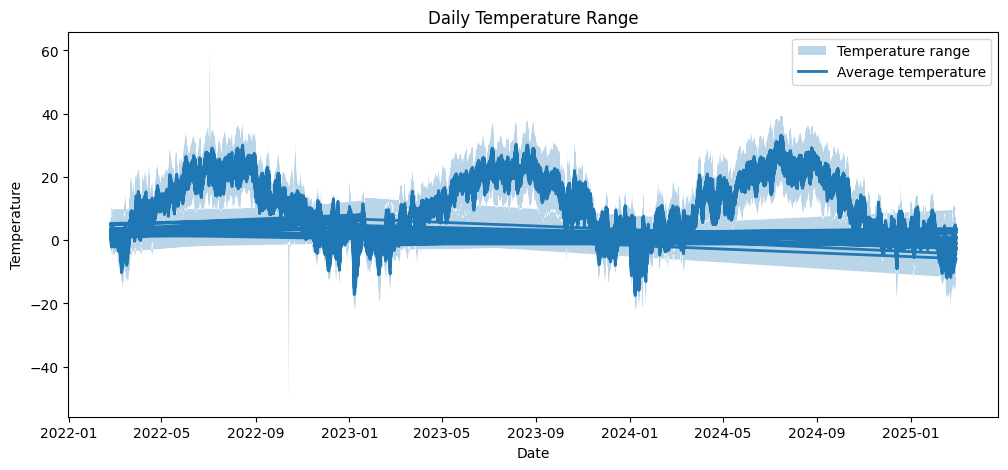

In [40]:
plt.figure(figsize=(12,5))

plt.fill_between(
    df_weather["day_datetime"],
    df_weather["day_tempmin"],
    df_weather["day_tempmax"],
    alpha=0.3,
    label="Temperature range"
)

plt.plot(
    df_weather["day_datetime"],
    df_weather["day_temp"],
    linewidth=2,
    label="Average temperature"
)

plt.title("Daily Temperature Range")
plt.xlabel("Date")
plt.ylabel("Temperature")

plt.legend()
plt.show()

### War events (alarms)

In [41]:
df_war_events_raw.shape

(55788, 6)

In [42]:
df_war_events_raw.head()

,id,region_id,region_city,all_region,start,end
0,52432,12,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28
1,53292,23,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43
2,52080,3,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42
3,52857,19,Харківська обл.,1,2022-02-24 20:11:47,2022-02-24 20:59:47
4,52700,18,Тернопільська обл.,1,2022-02-25 01:59:36,2022-02-25 09:00:19


In [43]:
df_war_events_raw.sample(5)

,id,region_id,region_city,all_region,start,end
15793,66004,15,Полтавська обл.,1,2023-02-06 22:59:42,2023-02-06 23:29:42
39607,140807,8,Запорізька обл.,1,2024-05-22 23:39:15,2024-05-23 00:08:57
35262,135916,10,Кіровоградська обл.,1,2024-03-17 22:26:26,2024-03-18 01:16:46
136,58,6,Житомирська обл.,1,2022-02-28 07:20:28,2022-02-28 07:42:44
38858,140145,23,Чернігівська обл.,1,2024-05-13 01:00:56,2024-05-13 01:28:49


In [44]:
df_war_events_raw.describe()

,id,region_id,all_region
count,55788.000000,55788.000000,55788.000000
mean,109103.029935,12.178121,0.972180
std,38574.559928,6.474089,0.164457
min,1.000000,1.000000,0.000000
25%,68259.750000,6.000000,1.000000
50%,126918.500000,13.000000,1.000000
75%,143399.250000,19.000000,1.000000
max,158665.000000,25.000000,1.000000


In [45]:
df_war_events_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 55788 entries, 0 to 55787
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           55788 non-null  int64
 1   region_id    55788 non-null  int64
 2   region_city  55788 non-null  str  
 3   all_region   55788 non-null  int64
 4   start        55788 non-null  str  
 5   end          55788 non-null  str  
dtypes: int64(3), str(3)
memory usage: 2.6 MB


In [46]:
print("Missing values:\n", df_war_events_raw.isna().sum())
print("\nDuplicate rows:", df_war_events_raw.duplicated().sum())
print("Duplicate id:", df_war_events_raw.duplicated(subset=["id"]).sum())

Missing values:
 id             0
region_id      0
region_city    0
all_region     0
start          0
end            0
dtype: int64

Duplicate rows: 0
Duplicate id: 0


In [47]:
df_war_events_raw[df_war_events_raw["all_region"] == 0]["region_city"].value_counts()

region_city
Київ    1552
Name: count, dtype: int64

In [48]:
df_war_events = df_war_events_raw.copy()

In [49]:
df_war_events["start"] = pd.to_datetime(df_war_events["start"], errors="coerce")
df_war_events["end"] = pd.to_datetime(df_war_events["end"], errors="coerce")

print("Invalid start dates:", df_war_events["start"].isna().sum())
print("Invalid end dates:", df_war_events["end"].isna().sum())

print(df_war_events[["start", "end"]].dtypes)

Invalid start dates: 0
Invalid end dates: 0
start    datetime64[us]
end      datetime64[us]
dtype: object


In [50]:
print("Min start:", df_war_events["start"].min())
print("Max start:", df_war_events["start"].max())

print("Min end:", df_war_events["end"].min())
print("Max end:", df_war_events["end"].max())

Min start: 2022-02-24 07:43:17
Max start: 2025-03-01 23:26:07
Min end: 2022-02-24 09:52:28
Max end: 2025-03-02 02:44:07


In [51]:
df_war_events["duration_min"] = (df_war_events["end"] - df_war_events["start"]).dt.total_seconds() / 60

print(df_war_events["duration_min"].describe())

count    55788.000000
mean        72.798103
std         93.094316
min       -781.700000
25%         26.566667
50%         39.733333
75%         84.716667
max       3031.300000
Name: duration_min, dtype: float64


In [52]:
print("Negative durations:", (df_war_events["duration_min"] < 0).sum())
print("Zero durations:", (df_war_events["duration_min"] == 0).sum())

Negative durations: 1
Zero durations: 0


In [53]:
df_war_events[df_war_events["duration_min"] < 0]

,id,region_id,region_city,all_region,start,end,duration_min
47970,150000,17,Сумська обл.,1,2024-10-01 20:53:04,2024-10-01 07:51:22,-781.7


One anomalous record with a **negative duration** was found

In [54]:
df_war_events["region_key"] = (
    df_war_events["region_city"]
    .str.replace(" обл.", "")
    .replace({"Крим": "АР Крим"})
)

In [55]:
df_war_events.head()

,id,region_id,region_city,all_region,start,end,duration_min,region_key
0,52432,12,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28,129.183333,Львівська
1,53292,23,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43,191.000000,Чернігівська
2,52080,3,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42,30.000000,Вінницька
3,52857,19,Харківська обл.,1,2022-02-24 20:11:47,2022-02-24 20:59:47,48.000000,Харківська
4,52700,18,Тернопільська обл.,1,2022-02-25 01:59:36,2022-02-25 09:00:19,420.716667,Тернопільська


In [56]:
alarm_regions = sorted(df_war_events[df_war_events["all_region"] == 1]["region_key"].unique())

regions = df_regions["region"]

missing_in_alarms = sorted(set(regions) - set(alarm_regions))
extra_in_alarms = sorted(set(alarm_regions) - set(regions))

print("Missing regions in alarms:", missing_in_alarms)
print("Extra regions in alarms:", extra_in_alarms)

Missing regions in alarms: ['Луганська']
Extra regions in alarms: []


**Luhansk region is missing** in the alarms dataset.

In [57]:
alarm_id_check = (
    df_war_events[["region_id", "region_key"]]
    .drop_duplicates()
    .rename(columns={"region_id": "region_id_alarms"})
)

regions_id_check = (
    df_regions[["region_id", "region"]]
    .rename(columns={"region_id": "region_id_regions", "region": "region_key"})
)

id_check = alarm_id_check.merge(regions_id_check, on="region_key")

id_mismatch = id_check[id_check["region_id_alarms"] != id_check["region_id_regions"]]

print("Number of ID mismatches:", len(id_mismatch))
id_mismatch

Number of ID mismatches: 19


,region_id_alarms,region_key,region_id_regions
0,12,Львівська,13
1,23,Чернігівська,25
2,3,Вінницька,2
3,19,Харківська,20
4,18,Тернопільська,19
5,16,Рівненська,17
6,22,Черкаська,23
7,14,Одеська,15
9,2,Волинська,3
11,20,Херсонська,21


In [58]:
region_id_map = df_regions.set_index("region")["region_id"].to_dict()

df_war_events["region_id"] = df_war_events["region_key"].map(region_id_map)
df_war_events.loc[df_war_events["region_key"] == "Київ", "region_id"] = 26

print("Missing region_id after remapping:", df_war_events["region_id"].isna().sum())
print(df_war_events[["region_city", "region_key", "region_id"]].sample(10))

Missing region_id after remapping: 0
                 region_city        region_key  region_id
10676  Дніпропетровська обл.  Дніпропетровська        4.0
32883          Донецька обл.          Донецька        5.0
44370          Донецька обл.          Донецька        5.0
1129           Київська обл.          Київська       10.0
9691           Донецька обл.          Донецька        5.0
50328          Донецька обл.          Донецька        5.0
39893                   Київ              Київ       26.0
20412      Миколаївська обл.      Миколаївська       14.0
14124      Закарпатська обл.      Закарпатська        7.0
22858         Волинська обл.         Волинська        3.0


In [59]:
alarm_id_check = (
    df_war_events[["region_id", "region_key"]]
    .drop_duplicates()
    .rename(columns={"region_id": "region_id_alarms"})
)

regions_id_check = (
    df_regions[["region_id", "region"]]
    .rename(columns={"region_id": "region_id_regions", "region": "region_key"})
)

id_check = alarm_id_check.merge(regions_id_check, on="region_key")

id_mismatch = id_check[id_check["region_id_alarms"] != id_check["region_id_regions"]]

print("Number of ID mismatches:", len(id_mismatch))

Number of ID mismatches: 0


In [60]:
plt.rcParams.update({
    "axes.edgecolor": "#DDDDDD",
    "axes.labelcolor": "#222222",
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.labelsize": 11,
    "xtick.color": "#444444",
    "ytick.color": "#444444",
    "xtick.labelsize": 9,
    "ytick.labelsize": 10,
    "grid.color": "#D9D9D9",
    "grid.alpha": 0.5,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE_DARK = "#1D4E89"
BLUE_MAIN = "#2F6DB3"
BLUE_SOFT = "#A9C6E8"
BLUE_LIGHT = "#DCEAF7"
RED_ACCENT = "#D1495B"
GOLD = "#F4A261"
TEXT_GREY = "#555555"

def style_ax(ax, grid_axis="y"):
    ax.grid(axis=grid_axis)
    ax.set_axisbelow(True)

def add_subtitle(fig, text):
    fig.text(0.125, 0.92, text, fontsize=10, color=TEXT_GREY)

In [61]:
df_plot = df_war_events.copy()

df_plot = df_plot[df_plot["duration_min"] > 0].copy() # keep only valid rows

df_plot["year_month"] = df_plot["start"].dt.to_period("M")
df_plot["hour"] = df_plot["start"].dt.hour
df_plot["weekday"] = df_plot["start"].dt.day_name()

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

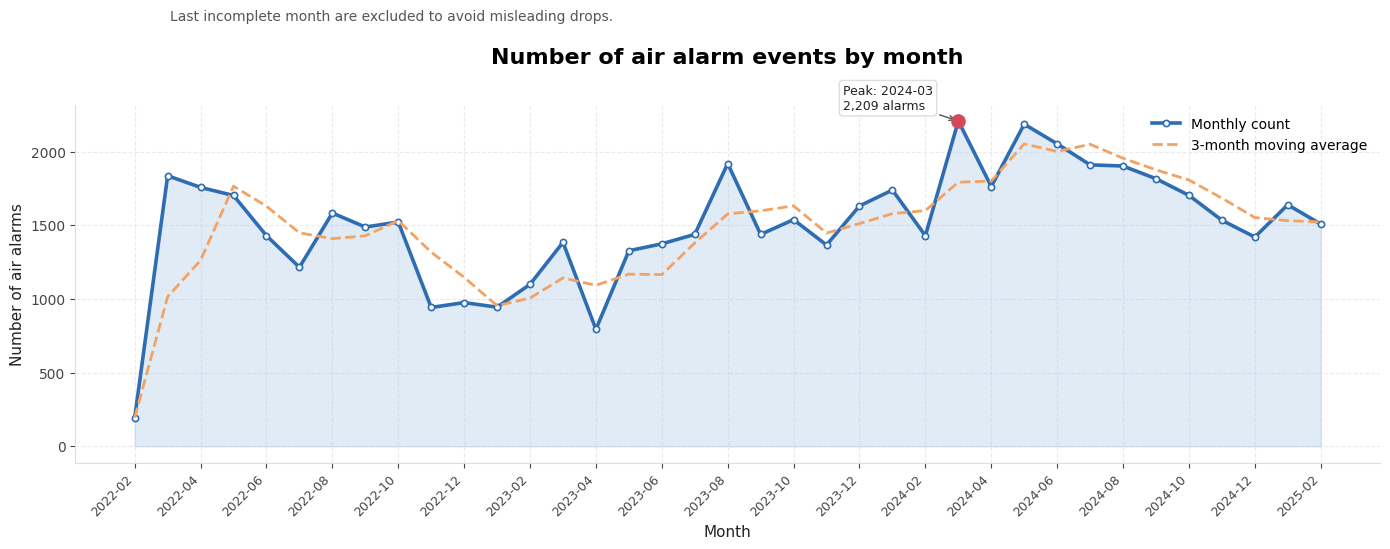

In [62]:
monthly_counts = df_plot.groupby("year_month").size().sort_index()
monthly_counts_plot = monthly_counts.iloc[:-1]

x_labels = monthly_counts_plot.index.astype(str).tolist()
y_values = monthly_counts_plot.values
x = np.arange(len(x_labels))
moving_avg = monthly_counts_plot.rolling(window=3, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(14, 5.8))
ax.fill_between(x, y_values, color=BLUE_SOFT, alpha=0.35)
ax.plot(
    x, y_values,
    color=BLUE_MAIN, linewidth=2.6,
    marker="o", markersize=4.5,
    markerfacecolor="white",
    markeredgewidth=1.2,
    label="Monthly count"
)

ax.plot(
    x, moving_avg,
    color=GOLD, linewidth=2,
    linestyle="--",
    label="3-month moving average"
)

peak_idx = int(np.argmax(y_values))
ax.scatter(x[peak_idx], y_values[peak_idx], s=90, color=RED_ACCENT, zorder=5)

ax.annotate(
    f"Peak: {x_labels[peak_idx]}\n{y_values[peak_idx]:,} alarms",
    xy=(x[peak_idx], y_values[peak_idx]),
    xytext=(x[peak_idx] - 3.5, y_values[peak_idx] + 80),
    arrowprops=dict(arrowstyle="->", color=TEXT_GREY),
    fontsize=9,
    color="#222222",
    bbox=dict(boxstyle="round", fc="white", ec="#DDDDDD")
)

tick_idx = np.arange(0, len(x_labels), 2)
ax.set_xticks(tick_idx)
ax.set_xticklabels([x_labels[i] for i in tick_idx], rotation=45, ha="right")

ax.set_title("Number of air alarm events by month", pad=30)
ax.set_xlabel("Month")
ax.set_ylabel("Number of air alarms")

ax.legend(frameon=False)

style_ax(ax, "both")
add_subtitle(fig, "Last incomplete month are excluded to avoid misleading drops.")

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

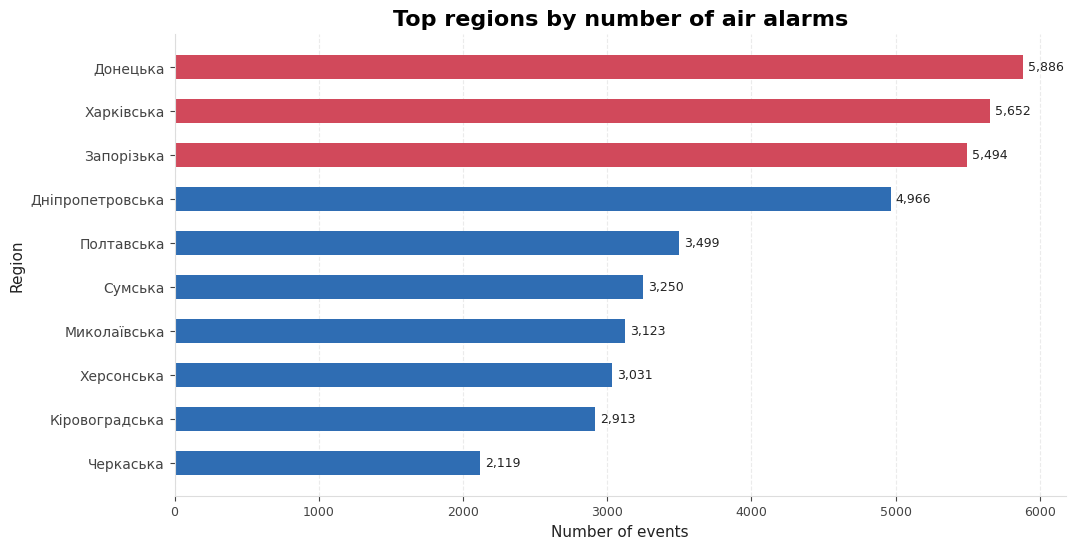

In [63]:
region_counts = df_plot.groupby("region_key").size().sort_values(ascending=False).head(10)

plot_region_counts = region_counts.sort_values()
top3_regions = set(region_counts.head(3).index)

bar_colors = [
    RED_ACCENT if region in top3_regions 
    else BLUE_MAIN for region in plot_region_counts.index
]

fig, ax = plt.subplots(figsize=(11.5, 6))

bars = ax.barh(
    plot_region_counts.index,
    plot_region_counts.values,
    color=bar_colors,
    height=0.55
)

for bar, value in zip(bars, plot_region_counts.values):
    ax.text(
        value + 35,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}",
        va="center",
        fontsize=9,
        color="#222222"
    )

ax.set_title("Top regions by number of air alarms")
ax.set_xlabel("Number of events")
ax.set_ylabel("Region")
style_ax(ax, "x")
plt.show()

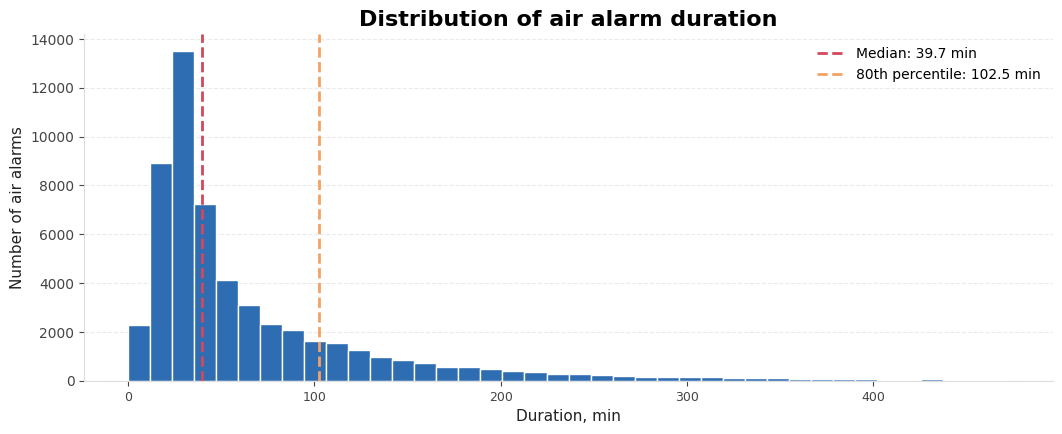

In [64]:
duration_min = df_plot["duration_min"].copy()
p99 = duration_min.quantile(0.99)
p80 = duration_min.quantile(0.80)
median_val = duration_min.median()

dur_clipped = duration_min[duration_min <= p99]

fig, ax = plt.subplots(figsize=(12.5, 4.5))

ax.hist(
    dur_clipped,
    bins=40,
    color=BLUE_MAIN,
    edgecolor="white"
)

ax.axvline(median_val, color=RED_ACCENT, linestyle="--", linewidth=2, label=f"Median: {median_val:.1f} min")
ax.axvline(p80, color=GOLD, linestyle="--", linewidth=2, label=f"80th percentile: {p80:.1f} min")

ax.set_title("Distribution of air alarm duration")
ax.set_xlabel("Duration, min")
ax.set_ylabel("Number of air alarms")
style_ax(ax, "y")
ax.legend(frameon=False, loc="upper right")
plt.show()

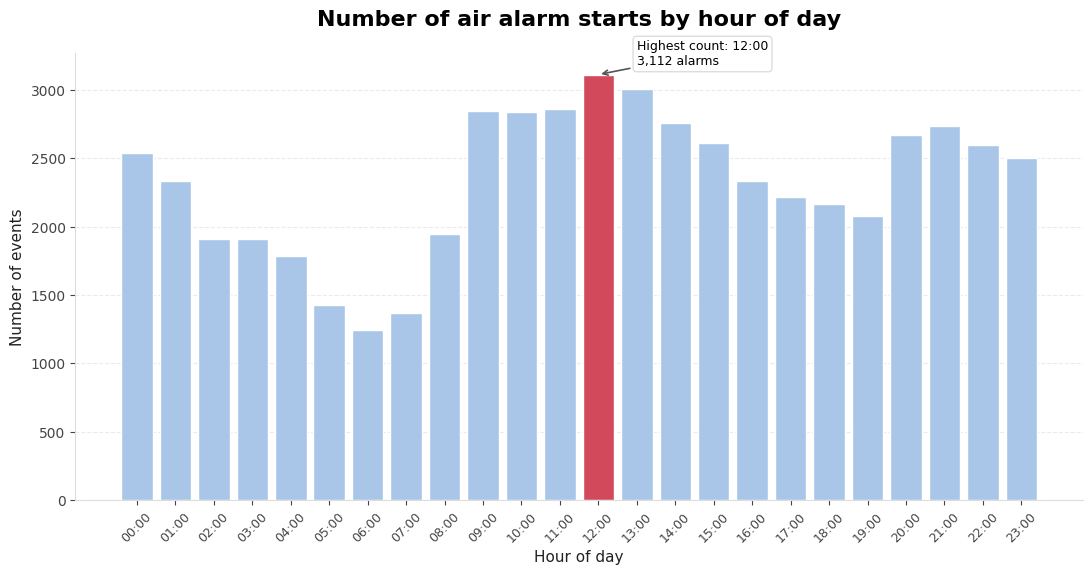

In [65]:
hour_counts = df_plot.groupby("hour").size()

top_hour = hour_counts.idxmax()
hour_colors = [BLUE_SOFT] * 24
hour_colors[top_hour] = RED_ACCENT

fig, ax = plt.subplots(figsize=(13, 5.8))
bars = ax.bar(
    hour_counts.index,
    hour_counts.values,
    color=hour_colors,
    edgecolor="white",
    width=0.82
)

ax.annotate(
    f"Highest count: {top_hour:02d}:00\n{hour_counts[top_hour]:,} alarms",
    xy=(top_hour, hour_counts[top_hour]),
    xytext=(top_hour + 1, hour_counts[top_hour] + 70),
    arrowprops=dict(arrowstyle="->", color=TEXT_GREY, lw=1.2),
    fontsize=9,
    bbox=dict(boxstyle="round", fc="white", ec="#DDDDDD")
)

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)
ax.set_title("Number of air alarm starts by hour of day", pad=20)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Number of events")
style_ax(ax, "y")
plt.show()

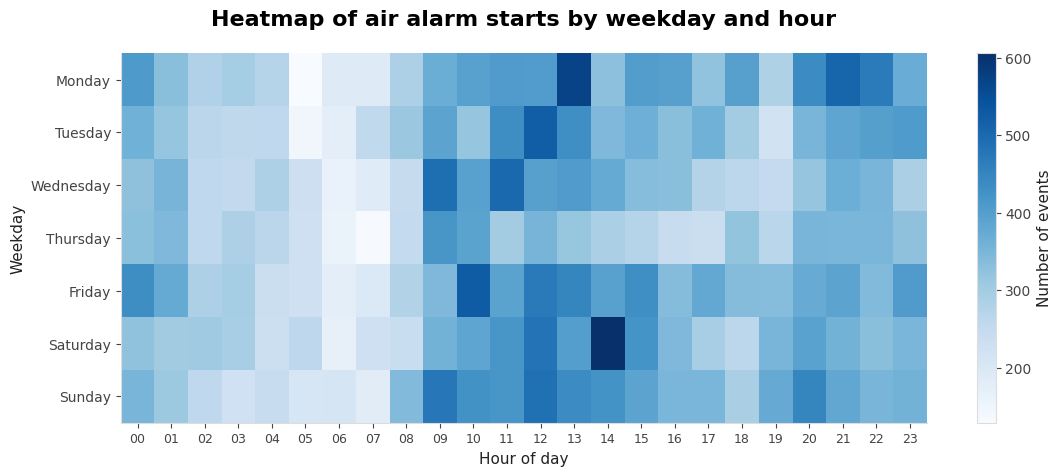

In [66]:
heatmap_data = (
    df_plot.groupby(["weekday", "hour"]).size()
    .reindex(pd.MultiIndex.from_product([weekday_order, range(24)]), fill_value=0)
    .unstack()
)

fig, ax = plt.subplots(figsize=(13, 4.8))
im = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    cmap="Blues"
)

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}" for h in range(24)])
ax.set_yticks(range(len(weekday_order)))
ax.set_yticklabels(weekday_order)

ax.set_title("Heatmap of air alarm starts by weekday and hour", pad=20)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Weekday")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of events")
plt.show()

### ISW

In [67]:
df_isw_raw.shape

(1467, 4)

In [68]:
df_isw_raw.head()

,date,title,url,text
0,2022-02-24,Russia-Ukraine Warning Update: Initial Russian...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...
1,2022-02-25,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...
2,2022-02-26,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...
3,2022-02-27,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Previous\nNext\nRussia-Ukraine Warning Update:...
4,2022-02-28,"Russian Offensive Campaign Assessment, Februar...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...


In [69]:
df_isw_raw.sample(5)

,date,title,url,text
374,2023-03-05,"Russian Offensive Campaign Assessment, March 5...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
352,2023-02-11,"Russian Offensive Campaign Assessment, Februar...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
110,2022-06-14,"Russian Offensive Campaign Assessment, June 14...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
439,2023-05-09,"Russian Offensive Campaign Assessment, May 9, ...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...
408,2023-04-08,"Russian Offensive Campaign Assessment, April 8...",https://understandingwar.org/research/russia-u...,Previous\nNext\nRussian Offensive Campaign Ass...


In [70]:
df_isw_raw.describe()

,date,title,url,text
count,1467,1467,1467,1467
unique,1467,1455,1455,1455
top,2022-02-24,None,None,None
freq,1,13,13,13


In [71]:
df_isw_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1467 entries, 0 to 1466
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   date    1467 non-null   str  
 1   title   1467 non-null   str  
 2   url     1467 non-null   str  
 3   text    1467 non-null   str  
dtypes: str(4)
memory usage: 46.0 KB


All columns currently have the `object` data type. 

In [72]:
df_isw = df_isw_raw.copy()

In [73]:
for col in ["date","title", "url", "text"]:
    df_isw[col] = df_isw[col].replace("None", np.nan)

In [74]:
df_isw["date"] = pd.to_datetime(df_isw["date"], errors="coerce")
print("Invalid dates:", df_isw["date"].isna().sum())
print(df_isw["date"].dtype)

Invalid dates: 0
datetime64[us]


In [75]:
outside_range = df_isw[(df_isw["date"] < "2022-02-24") | (df_isw["date"] > "2026-03-01")]
print(outside_range)

Empty DataFrame
Columns: [date, title, url, text]
Index: []


In [76]:
print("Missing values:", df_isw.isna().sum())

Missing values: date      0
title    13
url      13
text     13
dtype: int64


In [77]:
print("Duplicate dates:", df_isw["date"].duplicated().sum())
print("Duplicate non-missing titles:", df_isw["title"].dropna().duplicated().sum())
print("Duplicate non-missing urls:", df_isw["url"].dropna().duplicated().sum())
print("Duplicate non-missing text:", df_isw["text"].dropna().duplicated().sum())
print("Duplicate full rows:", df_isw.duplicated().sum())

Duplicate dates: 0
Duplicate non-missing titles: 0
Duplicate non-missing urls: 0
Duplicate non-missing text: 0
Duplicate full rows: 0


In [78]:
dup_dates = df_isw[df_isw["date"].duplicated(keep=False)]
dup_dates[["date", "title", "url"]]

,date,title,url


In [79]:
df_isw = df_isw.dropna(subset=["title", "url", "text"]).copy()

In [80]:
print("Missing values:", df_isw.isna().sum())

Missing values: date     0
title    0
url      0
text     0
dtype: int64


In [81]:
def clean_isw_text(text):
    text = str(text)
    text = text.replace("Previous\nNext", " ")
    text = text.replace("Click\nhere", " ")
    text = text.replace("\n", " ")
    return text

df_isw["text_clean"] = df_isw["text"].apply(clean_isw_text)

In [82]:
df_isw["text"] = df_isw["text_clean"]
df_isw = df_isw.drop(columns=["text_clean"])

In [83]:
df_isw.head()

,date,title,url,text
0,2022-02-24,Russia-Ukraine Warning Update: Initial Russian...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Initial Russi...
1,2022-02-25,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
2,2022-02-26,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
3,2022-02-27,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
4,2022-02-28,"Russian Offensive Campaign Assessment, Februar...",https://understandingwar.org/research/russia-u...,"Russian Offensive Campaign Assessment, Febru..."


In [84]:
df_isw_plot = df_isw.copy()

df_isw_plot["year"] = df_isw_plot["date"].dt.year
df_isw_plot["year_month"] = df_isw_plot["date"].dt.to_period("M")
df_isw_plot["word_count"] = df_isw_plot["text"].str.split().str.len()
df_isw_plot["char_count"] = df_isw_plot["text"].str.len()

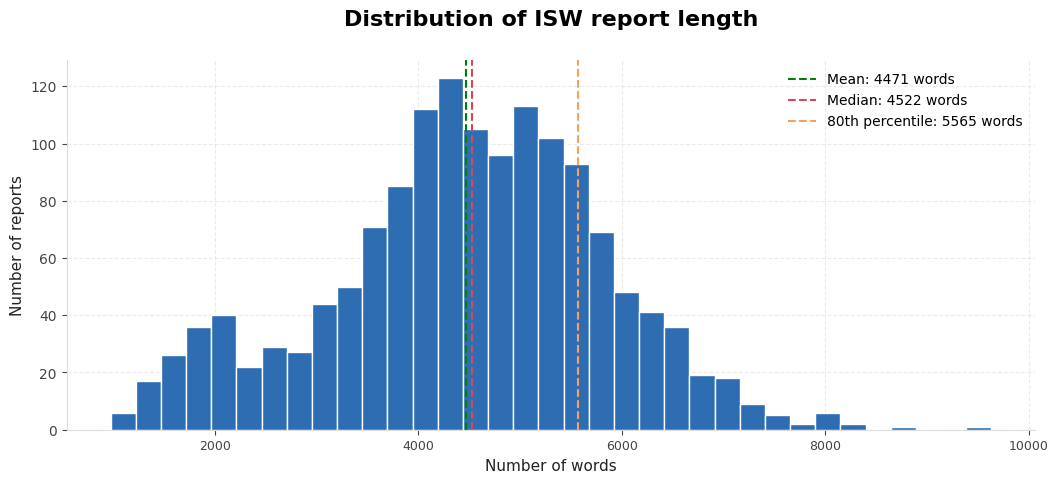

In [85]:
word_count = df_isw_plot["word_count"].copy()

p80 = word_count.quantile(0.80)
median_val = word_count.median()
mean_val = word_count.mean()

fig, ax = plt.subplots(figsize=(12.5, 4.8))
ax.hist(word_count, bins=35, color=BLUE_MAIN,edgecolor="white")

ax.axvline(
    mean_val,
    color="green",
    linestyle="--",
    label=f"Mean: {mean_val:.0f} words"
)
ax.axvline(
    median_val,
    color=RED_ACCENT,
    linestyle="--",
    label=f"Median: {median_val:.0f} words"
)
ax.axvline(
    p80,
    color=GOLD,
    linestyle="--",
    label=f"80th percentile: {p80:.0f} words"
)

ax.set_title("Distribution of ISW report length", pad=25)
ax.set_xlabel("Number of words")
ax.set_ylabel("Number of reports")
style_ax(ax, "both")
ax.legend(frameon=False, loc="upper right")
plt.show()

Distribution is not perfectly symmetric and appears to have tails on both sides, with most reports concentrated between roughly 4000 and 5500 words. 80% of reports are shorter than 5565 words.

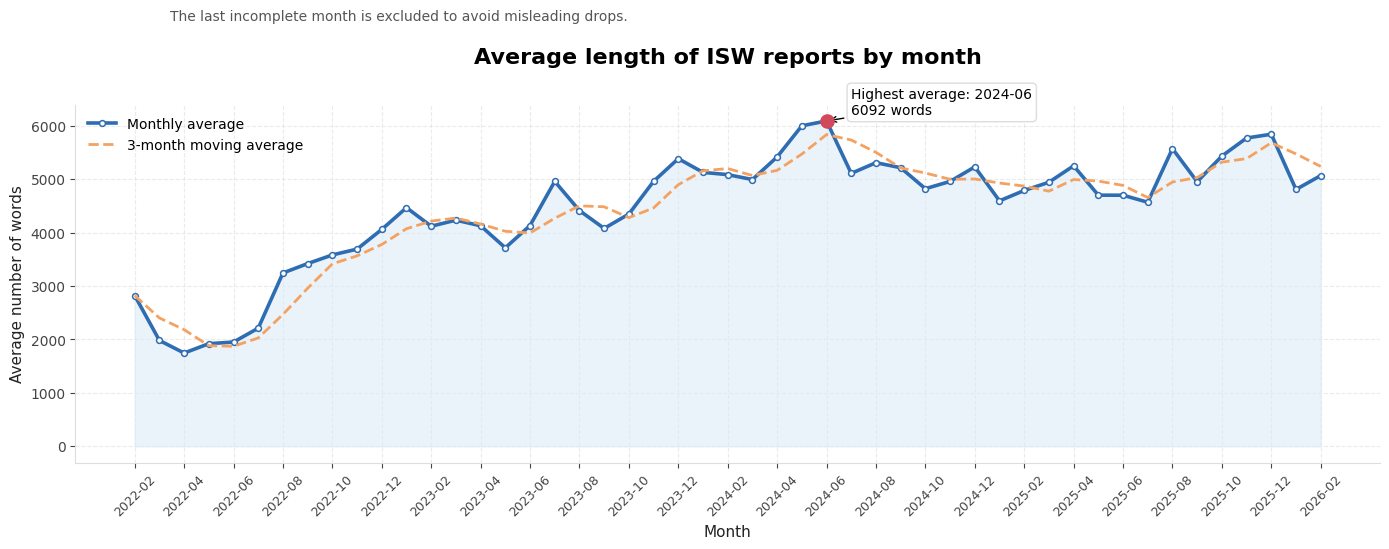

In [86]:
monthly_avg_words = df_isw_plot.groupby("year_month")["word_count"].mean().sort_index()
monthly_avg_words_plot = monthly_avg_words.iloc[:-1]

x_labels = monthly_avg_words_plot.index.astype(str).tolist()
y_values = monthly_avg_words_plot.values
x = np.arange(len(x_labels))
moving_avg = monthly_avg_words_plot.rolling(window=3, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(14, 5.8))
ax.fill_between(x, y_values, color=BLUE_LIGHT, alpha=0.55)
ax.plot(
    x, y_values,
    color=BLUE_MAIN, linewidth=2.6,
    marker="o", markersize=4.2,
    markerfacecolor="white",
    markeredgewidth=1.1,
    label="Monthly average"
)

ax.plot(
    x, moving_avg,
    color=GOLD, linewidth=2,
    linestyle="--",
    label="3-month moving average"
)

peak_idx = int(np.argmax(y_values))
ax.scatter(x[peak_idx], y_values[peak_idx], s=90, color=RED_ACCENT, zorder=5)
ax.annotate(
    f"Highest average: {x_labels[peak_idx]}\n{y_values[peak_idx]:.0f} words",
    xy=(x[peak_idx], y_values[peak_idx]),
    xytext=(max(0, x[peak_idx] + 1), y_values[peak_idx] + 120),
    arrowprops=dict(arrowstyle="->"),
    bbox=dict(boxstyle="round", fc="white", ec="#DDDDDD")
)

tick_idx = np.arange(0, len(x_labels), 2)
ax.set_xticks(tick_idx)
ax.set_xticklabels([x_labels[i] for i in tick_idx], rotation=45)

ax.set_title("Average length of ISW reports by month", pad=30)
ax.set_xlabel("Month")
ax.set_ylabel("Average number of words")

ax.legend(frameon=False)
style_ax(ax, "both")
add_subtitle(fig, "The last incomplete month is excluded to avoid misleading drops.")
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

Line chart shows that the average report length was lower in 2022 and became higher and more stable in later periods.

### Telegram 

In [87]:
df_tg_raw.shape

(129477, 3)

In [88]:
df_tg_raw.head()

,date,channel,message
0,2026-03-06 11:06:58+00:00,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...
1,2026-03-06 10:57:29+00:00,DeepStateUA,**🇺🇦**** Другий день обміну: додому **[**повер...
2,2026-03-06 06:32:47+00:00,DeepStateUA,🤬 **Угорщина затримала інкасаторські автомобіл...
3,2026-03-05 14:46:58+00:00,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...
4,2026-03-05 13:46:39+00:00,DeepStateUA,📋 **Зачистка з боку Сил Оборони на стику Запор...


In [89]:
df_tg_raw.sample(5)

,date,channel,message
91213,2025-07-24 22:49:57+00:00,kpszsu,🛵 Нові групи ворожих ударних БпЛА через Запорі...
26921,2024-11-19 12:37:45+00:00,UkraineNow,**У Київському районі Харкова вже 12 поранених...
53894,2023-01-16 06:32:06+00:00,UkraineNow,"❗️**У Запоріжжі троє поранених, серед них двоє..."
70854,2022-03-14 08:32:53+00:00,UkraineNow,**Київ: як працюватиме наземний громадський тр...
2778,2024-09-05 12:45:09+00:00,DeepStateUA,🇫🇷** Президент Франції призначив Мішеля Берньє...


In [90]:
df_tg_raw.describe()

,date,channel,message
count,129477,129477,129477
unique,129333,3,107432
top,2025-10-23 03:28:04+00:00,UkraineNow,📢 Відбій загрози.
freq,6,61363,929


In [91]:
df_tg_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 129477 entries, 0 to 129476
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   date     129477 non-null  str  
 1   channel  129477 non-null  str  
 2   message  129477 non-null  str  
dtypes: str(3)
memory usage: 3.0 MB


In [92]:
print("Unique channels:", df_tg_raw["channel"].nunique())
print(df_tg_raw["channel"].value_counts())

Unique channels: 3
channel
UkraineNow     61363
kpszsu         56272
DeepStateUA    11842
Name: count, dtype: int64


In [93]:
print("Duplicate rows:",
      df_tg_raw.duplicated(subset=["date", "channel", "message"]).sum())

print("Duplicate messages:",
      df_tg_raw.duplicated(subset=["message"]).sum())

Duplicate rows: 0
Duplicate messages: 22045


In [94]:
df_tg = df_tg_raw.copy()

In [95]:
df_tg["date"] = pd.to_datetime(df_tg["date"], utc=True, errors="coerce")
df_tg["date"] = df_tg["date"].dt.tz_convert("Europe/Kyiv")
df_tg["date"] = df_tg["date"].dt.tz_localize(None)

print("Invalid dates:", df_tg["date"].isna().sum())
print(df_tg["date"].dtype)

Invalid dates: 0
datetime64[us]


In [96]:
print("Min date:", df_tg["date"].min())
print("Max date:", df_tg["date"].max())

Min date: 2022-02-24 05:51:12
Max date: 2026-03-06 18:49:21


In [97]:
df_tg["message"] = df_tg["message"].astype(str)

print("Empty messages:", (df_tg["message"] == "").sum())
print("Whitespace messages:", df_tg["message"].str.strip().eq("").sum())

print("\nShortest messages:")
print(df_tg.loc[df_tg["message"].str.len().nsmallest(10).index, ["channel", "date", "message"]])

Empty messages: 0
Whitespace messages: 0

Shortest messages:
           channel                date message
1218   DeepStateUA 2025-06-01 14:49:49       🕸
4052   DeepStateUA 2024-02-16 14:20:06       🥪
7472   DeepStateUA 2022-11-11 13:10:16       🍉
9531   DeepStateUA 2022-04-12 21:46:52       😎
9804   DeepStateUA 2022-04-01 07:39:05       😳
10044  DeepStateUA 2022-03-22 18:42:05       💸
10163  DeepStateUA 2022-03-17 23:02:54       😐
10670  DeepStateUA 2022-03-04 18:47:06       🤨
10683  DeepStateUA 2022-03-04 14:53:13       🍾
10798  DeepStateUA 2022-03-03 09:02:20       🔴


In [98]:
CHANNEL_COLORS = {
    "UkraineNow": "green" ,
    "kpszsu": GOLD,
    "DeepStateUA": BLUE_DARK
}

In [99]:
df_tg["time"] = df_tg["date"].dt.strftime("%H:%M:%S")
df_tg["hour"] = df_tg["date"].dt.hour
df_tg["year_month"] = df_tg["date"].dt.to_period("M")
df_tg["date_day"] = df_tg["date"].dt.floor("D")

In [100]:
df_tg

,date,channel,message,time,hour,year_month,date_day
0,2026-03-06 13:06:58,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...,13:06:58,13,2026-03,2026-03-06
1,2026-03-06 12:57:29,DeepStateUA,**🇺🇦**** Другий день обміну: додому **[**повер...,12:57:29,12,2026-03,2026-03-06
2,2026-03-06 08:32:47,DeepStateUA,🤬 **Угорщина затримала інкасаторські автомобіл...,08:32:47,8,2026-03,2026-03-06
3,2026-03-05 16:46:58,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...,16:46:58,16,2026-03,2026-03-05
4,2026-03-05 15:46:39,DeepStateUA,📋 **Зачистка з боку Сил Оборони на стику Запор...,15:46:39,15,2026-03,2026-03-05
...,...,...,...,...,...,...,...
129472,2022-02-25 09:45:10,kpszsu,Вибухи на аеродромі Міллєрово в Ростовській об...,09:45:10,9,2022-02,2022-02-25
129473,2022-02-25 09:43:53,kpszsu,🛩🛩🛩🛩\nДо строю авіації Повітряних Сил Збройних...,09:43:53,9,2022-02,2022-02-25
129474,2022-02-25 00:43:47,kpszsu,ПОВІТРЯНІ СИЛИ ЗАВДАЛИ ВОРОГУ СУТТЄВИХ ВТРАТ\n...,00:43:47,0,2022-02,2022-02-25
129475,2022-02-25 00:43:23,kpszsu,https://fb.watch/bnMUkUvwfp/,00:43:23,0,2022-02,2022-02-25


In [101]:
df_tg_plot = df_tg.copy()

In [102]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]
df_tg_plot["weekday"] = pd.Categorical(
    df_tg_plot["date"].dt.day_name(),
    categories=weekday_order,
    ordered=True
)

df_tg_plot["message_len"] = df_tg_plot["message"].str.len()
df_tg_plot["word_count"] = df_tg_plot["message"].str.split().str.len()
df_tg_plot["is_duplicate_message"] = df_tg_plot.duplicated(subset=["message"], keep=False)

df_tg_plot.head()

,date,channel,message,time,hour,year_month,date_day,weekday,message_len,word_count,is_duplicate_message
0,2026-03-06 13:06:58,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...,13:06:58,13,2026-03,2026-03-06,Friday,606,42,False
1,2026-03-06 12:57:29,DeepStateUA,**🇺🇦**** Другий день обміну: додому **[**повер...,12:57:29,12,2026-03,2026-03-06,Friday,1171,116,False
2,2026-03-06 08:32:47,DeepStateUA,🤬 **Угорщина затримала інкасаторські автомобіл...,08:32:47,8,2026-03,2026-03-06,Friday,1477,140,False
3,2026-03-05 16:46:58,DeepStateUA,**🔄**** Мапу оновлено\n**\n⚔️ Ворог просунувся...,16:46:58,16,2026-03,2026-03-05,Thursday,669,44,False
4,2026-03-05 15:46:39,DeepStateUA,📋 **Зачистка з боку Сил Оборони на стику Запор...,15:46:39,15,2026-03,2026-03-05,Thursday,1740,208,False


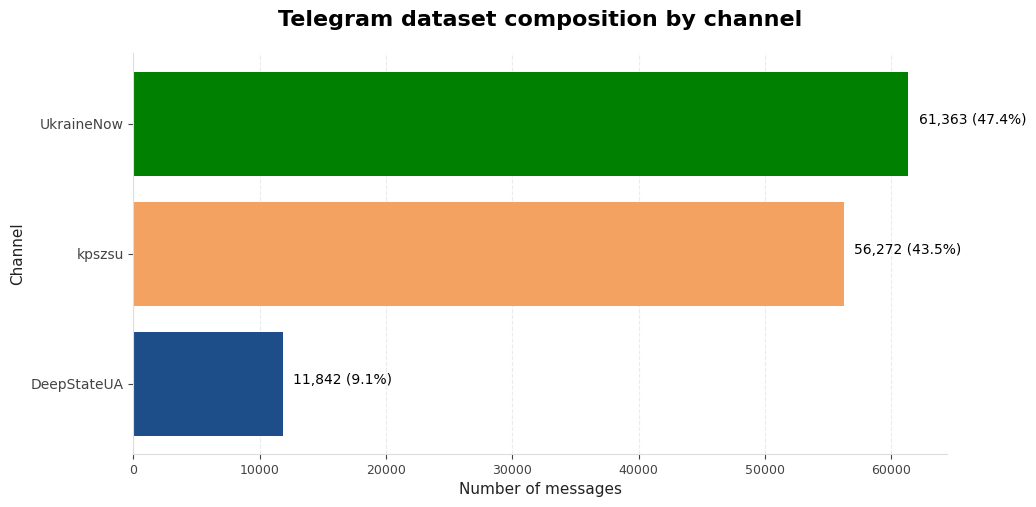

In [103]:
channel_counts = df_tg_plot["channel"].value_counts().sort_values()
channel_counts_percent = channel_counts / channel_counts.sum() * 100 

bar_colors = [CHANNEL_COLORS[channel] for channel in channel_counts.index]
fig, ax = plt.subplots(figsize=(10.5, 5.2))
bars = ax.barh(
    channel_counts.index,
    channel_counts.values,
    color=bar_colors,
)

for bar, count, share in zip(bars, channel_counts.values, channel_counts_percent.values):
    ax.text(
        count + 800,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({share:.1f}%)",
        fontsize=10
    )

ax.set_title("Telegram dataset composition by channel", pad=20)
ax.set_xlabel("Number of messages")
ax.set_ylabel("Channel")
style_ax(ax, "x")
plt.show()

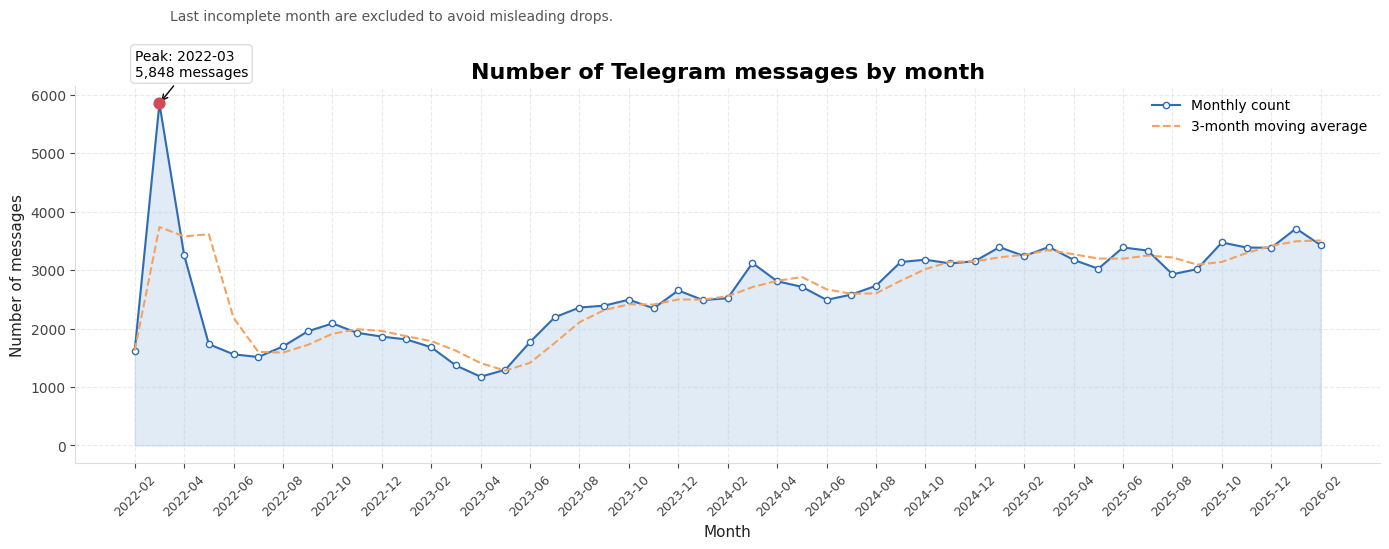

In [104]:
monthly_total = (df_tg_plot.groupby("year_month").size())

last_day = df_tg_plot["date"].max()
last_month_complete = last_day.day == last_day.days_in_month
if last_month_complete:
    monthly_total_plot = monthly_total.copy()
else:
    monthly_total_plot = monthly_total.iloc[:-1]

x_labels = monthly_total_plot.index.astype(str).tolist()
y_values = monthly_total_plot.values
x = np.arange(len(x_labels))
moving_avg = monthly_total_plot.rolling(window=3, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(14, 5.8))
ax.fill_between(x, y_values, color=BLUE_SOFT, alpha=0.35)
ax.plot(
    x, y_values,
    color=BLUE_MAIN,
    marker="o", markersize=4.5,
    markerfacecolor="white",
    label="Monthly count"
)
ax.plot(
    x, moving_avg,
    color=GOLD,
    linestyle="--",
    label="3-month moving average"
)

peak_idx = int(np.argmax(y_values))
ax.scatter(x[peak_idx], y_values[peak_idx], s=60, color=RED_ACCENT, zorder=5)
ax.annotate(
    f"Peak: {x_labels[peak_idx]}\n{y_values[peak_idx]:,} messages",
    xy=(x[peak_idx], y_values[peak_idx]),
    xytext=(max(0, x[peak_idx] - 4), y_values[peak_idx] + y_values.max() * 0.08),
    arrowprops=dict(arrowstyle="->"),
    bbox=dict(boxstyle="round", fc="white", ec="#DDDDDD")
)

tick_idx = np.arange(0, len(x_labels), 2)
ax.set_xticks(tick_idx)
ax.set_xticklabels([x_labels[i] for i in tick_idx], rotation=45)

ax.set_title("Number of Telegram messages by month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of messages")
ax.legend(frameon=False)
add_subtitle(fig, "Last incomplete month are excluded to avoid misleading drops.")
style_ax(ax, "both")
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

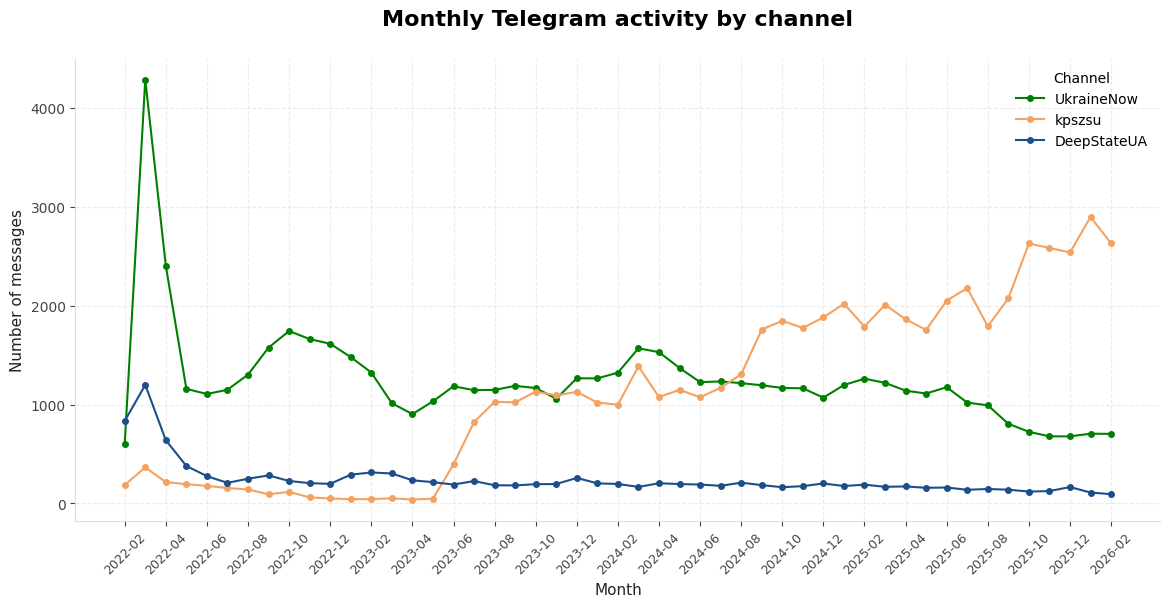

In [105]:
monthly_by_channel = (
    df_tg_plot.groupby(["year_month", "channel"])
    .size()
    .reset_index(name="messages_count")
)

if not last_month_complete:
    monthly_by_channel = monthly_by_channel[
        monthly_by_channel["year_month"] != monthly_by_channel["year_month"].max()
    ].copy()

monthly_by_channel["year_month_str"] = monthly_by_channel["year_month"].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))

for channel in ["UkraineNow", "kpszsu", "DeepStateUA"]:
    temp = monthly_by_channel[monthly_by_channel["channel"] == channel]
    ax.plot(
        temp["year_month_str"],
        temp["messages_count"],
        label=channel,
        color=CHANNEL_COLORS[channel],
        marker="o",
        markersize=4
    )

tick_idx = np.arange(0, monthly_by_channel["year_month_str"].nunique(), 2)
unique_months = monthly_by_channel["year_month_str"].drop_duplicates().tolist()

ax.set_xticks(tick_idx)
ax.set_xticklabels([unique_months[i] for i in tick_idx], rotation=45)
ax.set_title("Monthly Telegram activity by channel", pad=24)
ax.set_xlabel("Month")
ax.set_ylabel("Number of messages")
ax.legend(title="Channel", frameon=False)
style_ax(ax, "both")
plt.show()

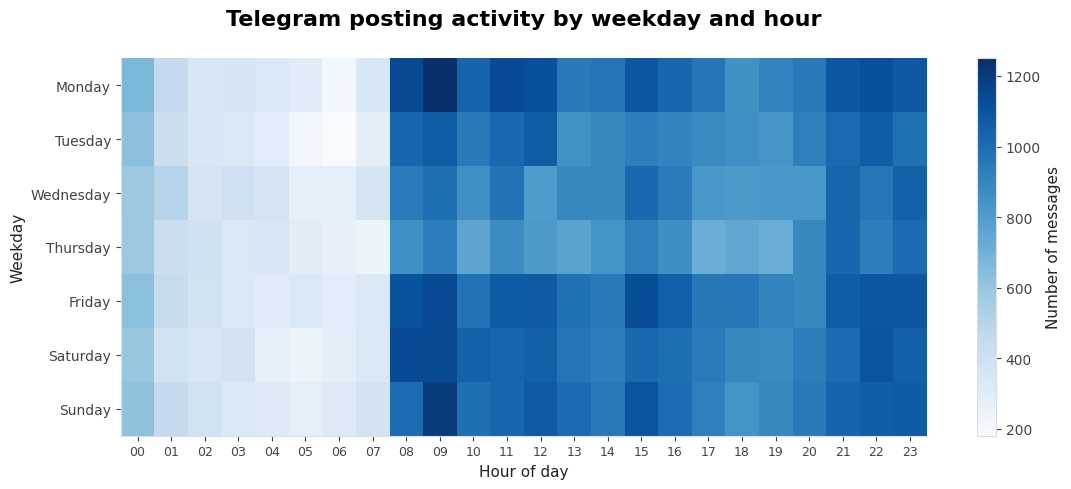

In [106]:
heatmap_data = (
    df_tg_plot.groupby(["weekday", "hour"])
    .size()
    .reindex(pd.MultiIndex.from_product([weekday_order, range(24)]), fill_value=0)
    .unstack()
)

fig, ax = plt.subplots(figsize=(13, 4.9))
im = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    cmap="Blues"
)

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}" for h in range(24)])
ax.set_yticks(range(len(weekday_order)))
ax.set_yticklabels(weekday_order)

ax.set_title("Telegram posting activity by weekday and hour", pad=24)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Weekday")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of messages")
plt.show()

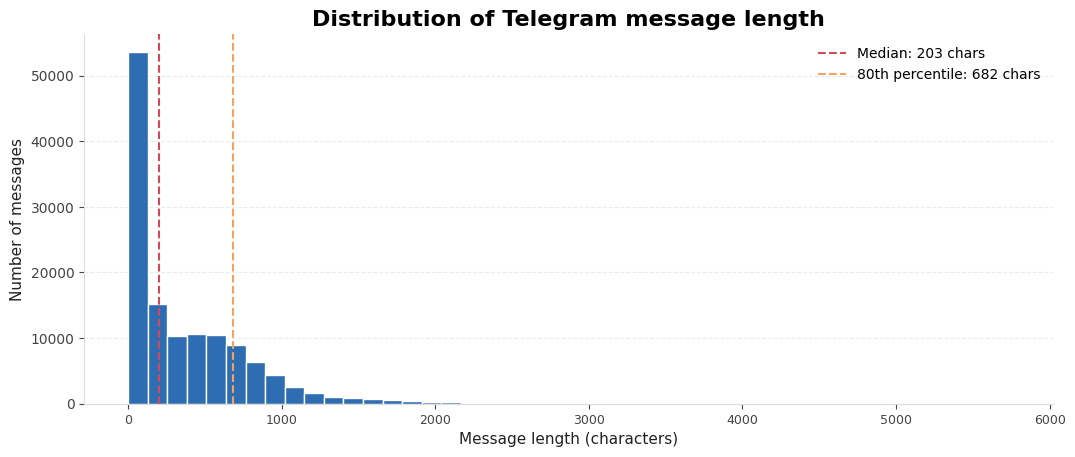

In [107]:
message_len = df_tg_plot["message_len"].copy()

p80 = message_len.quantile(0.80)
median_val = message_len.median()

fig, ax = plt.subplots(figsize=(12.5, 4.8))
ax.hist(
    message_len,
    bins=45,
    color=BLUE_MAIN,
    edgecolor="white",
)

ax.axvline(
    median_val,
    color=RED_ACCENT,
    linestyle="--",
    label=f"Median: {median_val:.0f} chars"
)

ax.axvline(
    p80,
    color=GOLD,
    linestyle="--",
    label=f"80th percentile: {p80:.0f} chars"
)

ax.set_title("Distribution of Telegram message length")
ax.set_xlabel("Message length (characters)")
ax.set_ylabel("Number of messages")
ax.legend(frameon=False, loc="upper right")
style_ax(ax, "y")
plt.show()

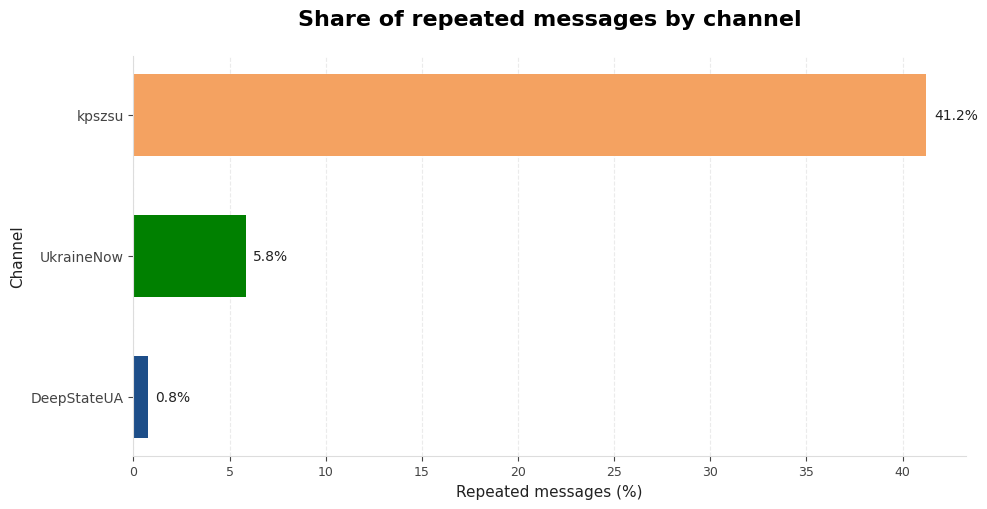

In [108]:
dup_share = (
    df_tg_plot.groupby("channel")["is_duplicate_message"]
    .mean()
    .mul(100)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5.2))

bars = ax.barh(
    dup_share.index,
    dup_share.values,
    color=[CHANNEL_COLORS[ch] for ch in dup_share.index],
    height=0.58
)

for bar, value in zip(bars, dup_share.values):
    ax.text(
        value + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=10,
        color="#222222"
    )

ax.set_title("Share of repeated messages by channel", pad=22)
ax.set_xlabel("Repeated messages (%)")
ax.set_ylabel("Channel")

style_ax(ax, "x")
plt.tight_layout()
plt.show()

## IV. Prepare data

### ISW

In [109]:
df_isw.head()

,date,title,url,text
0,2022-02-24,Russia-Ukraine Warning Update: Initial Russian...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Initial Russi...
1,2022-02-25,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
2,2022-02-26,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
3,2022-02-27,Russia-Ukraine Warning Update: Russian Offensi...,https://understandingwar.org/research/russia-u...,Russia-Ukraine Warning Update: Russian Offen...
4,2022-02-28,"Russian Offensive Campaign Assessment, Februar...",https://understandingwar.org/research/russia-u...,"Russian Offensive Campaign Assessment, Febru..."


In [110]:
df_isw['text'] = df_isw['text'].str.lower()

In [111]:
df_isw['text'] = df_isw['text'].str.replace(f"[{string.punctuation}]", "", regex=True)

1. Підготовка

In [112]:
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))
isw_word_cache = {}

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\slava\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [126]:
def smart_preprocess_cached(text):
    text = str(text).lower()

    # Очистка
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\b(?:https|http|www)\S*\b', ' ', text)  #поламані URL

    text = re.sub(r'\b(?:twitter|facebook|telegram|youtube|instagram|isw)\S*\b', ' ', text)
    text = re.sub(r'\b(previous|next|click here|dot)\b', ' ', text)
    text = re.sub(r'[^a-z\s-]', ' ', text)
    text = re.sub(r'\b\d+\b', '', text)

    words = text.split()
    clean_words = []

    for w in words:
        # ПЕРЕВІРКА СТОП-СЛІВ
        if w in stop_words or len(w) <= 2:
            continue

        # КЕШУВАННЯ ЛЕМАТИЗАЦІЇ
        if w not in isw_word_cache:
            isw_word_cache[w] = lemmatizer.lemmatize(w)

        clean_words.append(isw_word_cache[w])

    return " ".join(clean_words)

2. Застосування

In [127]:
tqdm.pandas()
print("Обробка текстів ISW...")
df_isw['text_final'] = df_isw['text'].progress_apply(smart_preprocess_cached)

Обробка текстів ISW...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1454/1454 [00:08<00:00, 166.33it/s]


3. Векторизація

In [128]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=5)
X = vectorizer.fit_transform(df_isw['text_final'])

4. Результати

In [129]:
print(f"Розмірність матриці: {X.shape}")
feature_names = vectorizer.get_feature_names_out()
print("Перші 20 ознак (тепер точно слова):")
print(feature_names[:20])

Розмірність матриці: (1454, 5000)
Перші 20 ознак (тепер точно слова):
['abandon' 'abandoned' 'ability' 'able' 'abroad' 'accept' 'access'
 'access archive' 'accession' 'according' 'account' 'accumulating'
 'accusation' 'accused' 'accusing' 'achieve' 'achieved' 'achieving'
 'acknowledged' 'across']


5. EDA

In [130]:
from collections import Counter

all_words = " ".join(df_isw['text_final']).split()
word_counts = Counter(all_words)

print("20 most common words:", word_counts.most_common(20))

20 most common words: [('russian', 224315), ('force', 108639), ('ukrainian', 92638), ('near', 46392), ('ukraine', 41174), ('oblast', 40625), ('military', 32957), ('claimed', 31371), ('russia', 30070), ('effort', 28087), ('reported', 24633), ('operation', 23197), ('area', 22841), ('drone', 20366), ('continued', 18188), ('offensive', 17850), ('city', 16620), ('direction', 16607), ('stated', 16143), ('reportedly', 15427)]


In [131]:
df_isw['doc_length'] = df_isw['text_final'].apply(lambda x: len(x.split()))

print("Document duration statistics:")
print(df_isw['doc_length'].describe())

Document duration statistics:
count    1454.000000
mean     2707.194635
std       820.394181
min       601.000000
25%      2246.250000
50%      2747.000000
75%      3261.000000
max      5741.000000
Name: doc_length, dtype: float64


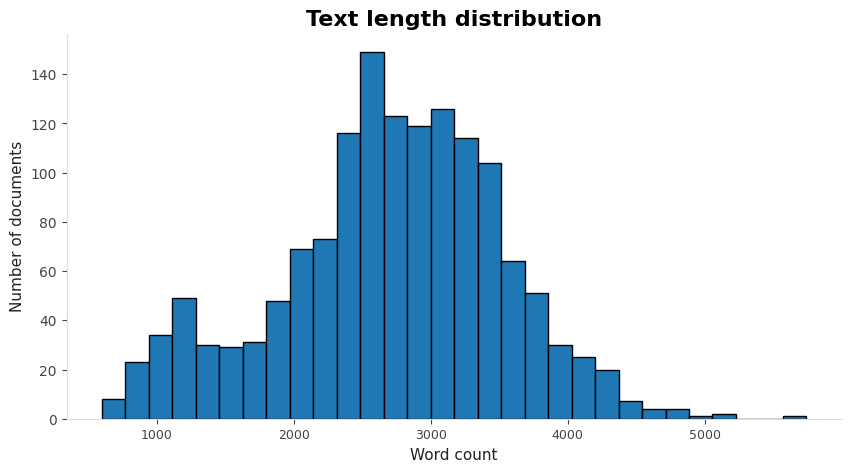

In [132]:
plt.figure(figsize=(10,5))
plt.hist(df_isw['doc_length'], bins=30, edgecolor='black')
plt.title("Text length distribution")
plt.xlabel("Word count")
plt.ylabel("Number of documents")
plt.show()

In [133]:
doc_count = {}
for text in df_isw['text_final']:
    tokens = set(text.split()) 
    for token in tokens:
        doc_count[token] = doc_count.get(token, 0) + 1

total_docs = len(df_isw)
top_doc_words = sorted(doc_count.items(), key=lambda x: x[1], reverse=True)[:20]

print("\n Top-20 most popular words(ISW):")
for token, count in top_doc_words:
    print(f"{token}: {count}/{total_docs} = {count/total_docs:.2%}")


 Top-20 most popular words(ISW):
russian: 1454/1454 = 100.00%
oblast: 1454/1454 = 100.00%
offensive: 1454/1454 = 100.00%
campaign: 1454/1454 = 100.00%
operation: 1454/1454 = 100.00%
ukrainian: 1454/1454 = 100.00%
assessment: 1454/1454 = 100.00%
force: 1454/1454 = 100.00%
ukraine: 1454/1454 = 100.00%
russia: 1453/1454 = 99.93%
military: 1453/1454 = 99.93%
key: 1453/1454 = 99.93%
reported: 1453/1454 = 99.93%
effort: 1452/1454 = 99.86%
report: 1451/1454 = 99.79%
continued: 1451/1454 = 99.79%
city: 1450/1454 = 99.72%
continue: 1449/1454 = 99.66%
western: 1449/1454 = 99.66%
claimed: 1448/1454 = 99.59%


In [134]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000, min_df=5)
X = vectorizer.fit_transform(df_isw['text_final'])

print("TF-IDF матриця:", X.shape)
sparsity = 1.0 - X.nnz / (X.shape[0] * X.shape[1])
print(f"Sparsity (частка нульових елементі): {sparsity:.2%}")

TF-IDF матриця: (1454, 5000)
Sparsity (частка нульових елементі): 73.58%


In [135]:
idf_scores = dict(zip(vectorizer.get_feature_names_out(), vectorizer.idf_))
top_idf = sorted(idf_scores.items(), key=lambda x: x[1], reverse=True)[:20]
print("\nТоп-20 термінів за IDF (рідкісні, зважені):")
for term, score in top_idf:
    print(f"{term}: {score:.2f}")


Топ-20 термінів за IDF (рідкісні, зважені):
truce: 4.95
unilateral: 4.88
russianclaimed advance: 4.85
june advance: 4.82
mdcoa: 4.79
march advance: 4.76
may advance: 4.76
july advance: 4.70
russianclaimed: 4.67
direction april: 4.59
bed: 4.55
roc: 4.55
popov: 4.52
june make: 4.50
direction march: 4.48
georgian: 4.45
may make: 4.41
alaska summit: 4.37
moratorium: 4.35
october advance: 4.35


In [136]:
df_isw['text_len'] = df_isw['text_final'].str.len()

# Створюємо денний таргет (наприклад, 1 якщо була тривога в Україні, 0 якщо ні)
# Приклад злиття з твоїми даними alarms:
daily_target = df_war_events.groupby(df_war_events['start'].dt.date).size().rename('alarm_count')
df_isw['is_alarm'] = df_isw['date'].dt.date.map(lambda d: 1 if d in daily_target.index else 0)

print(f"Кореляція довжини звіту та тривоги: {df_isw['text_len'].corr(df_isw['is_alarm']):.4f}")

Кореляція довжини звіту та тривоги: -0.2813


In [137]:
from sklearn.feature_selection import chi2

# Рахуємо Chi-square для всіх 5000 слів
chi2_score, p_val = chi2(X, df_isw['is_alarm'])

# Створюємо таблицю результатів
chi2_df = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'score': chi2_score
}).sort_values('score', ascending=False)

print("Топ-20 статистично найважливіших слів за Chi-square:")
print(chi2_df.head(20))

Топ-20 статистично найважливіших слів за Chi-square:
                     word      score
3129         order battle  55.554137
2885         novopavlivka  46.774954
4685    unconfirmed claim  46.756211
3261             pokrovsk  43.794638
1579       force attacked  38.202385
1281       drone operator  35.916288
1237          dobropillya  33.612872
4684          unconfirmed  32.973977
3662  reportedly striking  30.309872
3116             operator  30.208621
60    advance unconfirmed  29.691140
4370            sumy city  29.250383
4325   striking ukrainian  28.482065
4527               toward  27.723424
2184       kostyantynivka  27.546925
458                battle  27.352156
4768    velykomykhailivka  26.426860
4369                 sumy  25.579807
1273                drone  25.354458
460          battle drone  23.616744


### Telegram

In [138]:
tqdm.pandas()
morph = pymorphy3.MorphAnalyzer(lang='uk')
word_cache = {}

def fast_tg_clean_optimized(text):
    text = re.sub(r'https?://\S+|@\w+', '', str(text).lower())
    text = re.sub(r'[^а-яіїєґa-z\s-]', ' ', text)
    words = text.split()

    res = []
    for w in words:
        if len(w) < 3: continue

        if w not in word_cache:
            word_cache[w] = morph.parse(w)[0].normal_form
        res.append(word_cache[w])

    return " ".join(res)

print("Починаю очистку ТГ (це займе пару хвилин)...")
df_tg['message_clean'] = df_tg['message'].progress_apply(fast_tg_clean_optimized)

Починаю очистку ТГ (це займе пару хвилин)...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 129477/129477 [00:18<00:00, 6968.26it/s]


In [139]:
vectorizer_tg = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    dtype=np.float32
)
X_tg = vectorizer_tg.fit_transform(df_tg['message_clean'])

print(X_tg.shape)

(129477, 5000)


In [140]:
from collections import Counter

all_words = " ".join(df_tg['message_clean']).split()
word_counts = Counter(all_words)

# топ-20 найчастіших слів
print("20 найчастіших слів:", word_counts.most_common(20))

# перевірка, чи залишився шум

20 найчастіших слів: [('україна', 58883), ('бпла', 45866), ('область', 34811), ('напрямок', 34799), ('для', 30191), ('про', 28995), ('який', 28339), ('російський', 25477), ('бути', 25419), ('наш', 23756), ('ворожий', 22998), ('курс', 21135), ('ворог', 20567), ('загроза', 19593), ('сила', 18990), ('район', 18162), ('росія', 17070), ('від', 16664), ('також', 16045), ('telegram', 15822)]


In [141]:
# 1. Створюємо список дат з тривогами
all_alarm_dates = pd.to_datetime(df_war_events['start']).dt.date.unique()

# 2. Додаємо мітку в df_tg (1 - день з тривогою, 0 - без)
df_tg['date_only'] = pd.to_datetime(df_tg['date']).dt.date
df_tg['is_alarm'] = df_tg['date_only'].isin(all_alarm_dates).astype(int)

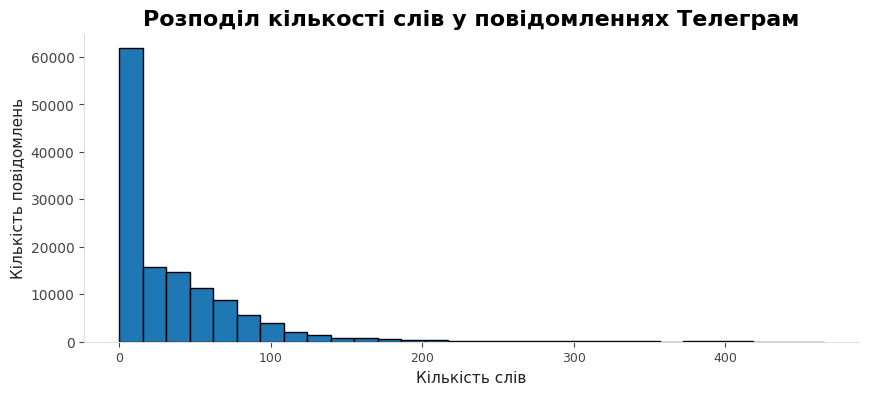

In [142]:
df_tg['word_count'] = df_tg['message_clean'].str.split().str.len()

plt.figure(figsize=(10, 4))
plt.hist(df_tg['word_count'], bins=30, edgecolor='black')  # bins = кількість стовпчиків

plt.title('Розподіл кількості слів у повідомленнях Телеграм')
plt.xlabel('Кількість слів')
plt.ylabel('Кількість повідомлень')

plt.show()

In [143]:
# --- 2. Sparsity (Наскільки "порожня" матриця ТГ) ---
sparsity_tg = (1 - X_tg.nnz / (X_tg.shape[0] * X_tg.shape[1])) * 100
print(f"Sparsity матриці Telegram: {sparsity_tg:.4f}%")

Sparsity матриці Telegram: 99.3415%


In [144]:
X_tg_df = pd.DataFrame(X_tg.toarray(), columns=vectorizer_tg.get_feature_names_out())

X_tg_df['is_alarm'] = df_tg['is_alarm'].values

mean_weights_tg = X_tg_df.groupby('is_alarm').mean()

tfidf_diff_tg = (mean_weights_tg.loc[1] - mean_weights_tg.loc[0]).sort_values(ascending=False)

print("Топ-20 слів за TF-IDF, що асоціюються з тривогою (Telegram):")
print(tfidf_diff_tg.head(20).to_string())

Топ-20 слів за TF-IDF, що асоціюються з тривогою (Telegram):
тривога                  0.019298
україна                  0.015019
ukraine                  0.013554
now                      0.013271
ukraine now              0.013228
повітряний               0.012824
підписуватися            0.011743
підписуватися ukraine    0.011719
відбій                   0.011463
повітряний тривога       0.011449
область                  0.011406
наш                      0.010821
увага                    0.009577
ракетний                 0.009302
небезпека                0.007699
окупант                  0.007596
відбій загроза           0.007528
бути                     0.007460
область тривога          0.007089
ракетний небезпека       0.007067


In [145]:
trash_words = [
    'підписуватися'
]

vectorizer_tg = TfidfVectorizer(
    max_features=5000, 
    ngram_range=(1, 2), 
    stop_words=trash_words,
    dtype=np.float32
)

X_tg = vectorizer_tg.fit_transform(df_tg['message_clean'])

In [146]:
X_tg_df = pd.DataFrame(X_tg.toarray(), columns=vectorizer_tg.get_feature_names_out())

X_tg_df['is_alarm'] = df_tg['is_alarm'].values

mean_weights_tg = X_tg_df.groupby('is_alarm').mean()

# 4. Різниця ваг: тривога - без тривоги
tfidf_diff_tg = (mean_weights_tg.loc[1] - mean_weights_tg.loc[0]).sort_values(ascending=False)

# 5. Виводимо топ-20
print("Топ-20 слів за TF-IDF, що асоціюються з тривогою (Telegram):")
print(tfidf_diff_tg.head(20).to_string())

Топ-20 слів за TF-IDF, що асоціюються з тривогою (Telegram):
тривога               0.019337
україна               0.015051
ukraine               0.013766
now                   0.013485
ukraine now           0.013442
повітряний            0.012864
повітряний тривога    0.011481
відбій                0.011465
область               0.011440
наш                   0.010827
увага                 0.009586
ракетний              0.009327
небезпека             0.007725
окупант               0.007603
відбій загроза        0.007528
бути                  0.007476
ракетний небезпека    0.007092
область тривога       0.007089
російський            0.007065
сила                  0.006942


In [147]:
scores_tg, _ = chi2(X_tg, df_tg['is_alarm'])

chi2_df_tg = pd.DataFrame({
    'word': vectorizer_tg.get_feature_names_out(),
    'score': scores_tg
}).sort_values('score', ascending=False)

print("Топ-20 статистично найважливіших слів за Chi-square (TG):")
print(chi2_df_tg.head(20).to_string(index=False))

Топ-20 статистично найважливіших слів за Chi-square (TG):
             word       score
             бпла 2089.536877
whatsapp telegram 2070.766283
   telegram viber 2068.762068
              каб 1657.157296
             курс 1646.066022
         пуск каб 1082.550949
          півночі 1079.043041
    бпла напрямок 1069.582562
    каб донеччина 1025.183979
        донеччина  848.443601
         whatsapp  814.029669
             повз  813.317354
            viber  812.659922
         telegram  784.176912
             пуск  759.937757
          сумщина  713.434285
     бпла півночі  662.992566
        бпла курс  660.246131
       харківщина  635.696255
 дніпропетровщина  630.021711


In [148]:
trash_words = [
    'viber', 'whatsapp', 'telegram'
]

vectorizer_tg = TfidfVectorizer(
    max_features=5000, 
    ngram_range=(1, 2), 
    stop_words=trash_words, 
    dtype=np.float32
)

X_tg = vectorizer_tg.fit_transform(df_tg['message_clean'])


In [149]:
# --- 3. Chi-square (Топ слів-маркерів у Телеграмі) ---
# Використовуємо X_tg та нашу нову колонку is_alarm
scores_tg, _ = chi2(X_tg, df_tg['is_alarm'])
chi2_df_tg = pd.DataFrame({'word': vectorizer_tg.get_feature_names_out(), 'score': scores_tg})
top_features_tg = chi2_df_tg.sort_values(by='score', ascending=False).head(20)

from sklearn.feature_selection import chi2

# 1. Рахуємо Chi-square для ТГ (X_tg — твоя матриця, is_alarm — таргет)
scores_tg, p_val_tg = chi2(X_tg, df_tg['is_alarm'])

# 2. Створюємо таблицю результатів для ТГ
chi2_df_tg = pd.DataFrame({
    'word': vectorizer_tg.get_feature_names_out(),
    'score': scores_tg
}).sort_values('score', ascending=False)

# 3. Виводимо топ-20
print("Топ-20 статистично найважливіших слів за Chi-square (Telegram):")
print(chi2_df_tg.head(20).to_string(index=False))

Топ-20 статистично найважливіших слів за Chi-square (Telegram):
            word       score
            бпла 2087.340695
             каб 1659.065308
            курс 1644.478645
        пуск каб 1085.442078
         півночі 1079.724773
   бпла напрямок 1068.018459
   каб донеччина 1026.452103
       донеччина  851.634023
            повз  812.634490
            пуск  760.886015
         сумщина  713.634856
    бпла півночі  662.551324
       бпла курс  657.688287
      харківщина  637.935489
дніпропетровщина  630.998877
    чернігівщина  622.537651
      група бпла  615.180071
         тривога  606.416253
            сход  555.270067
       бпла сход  532.757625


In [ ]:
#я не дуже впевнена щодо чистки слів, може це треба на початок додати, просто помітила я тільки вже при еда

### War events (alarms)

In [ ]:
df_war_events.head()

In [ ]:
df_war_events = df_war_events[df_war_events["duration_min"] >= 0].copy()
print("Shape after removing negative durations:", df_war_events.shape)

In [ ]:
print("Negative durations:", (df_war_events["duration_min"] < 0).sum())

In [ ]:
rows = []

for row in df_war_events[["id", "region_id", "region_key", "start", "end"]].itertuples(index=False):
    start_hour = row.start.floor("h")
    end_hour = row.end.floor("h")

    for hour in pd.date_range(start_hour, end_hour, freq="h"):
        hour_end = hour + pd.Timedelta(hours=1)

        overlap_start = max(row.start, hour)
        overlap_end = min(row.end, hour_end)

        overlap_min = (overlap_end - overlap_start).total_seconds() / 60

        if overlap_min > 0:
            rows.append({
                "datetime_hour": hour,
                "region_id": row.region_id,
                "region_key": row.region_key,
                "alarm_minutes_in_hour": overlap_min,
                "alarm_active": 1,
                "alarm_id": row.id
            })

df_alarm_hourly = pd.DataFrame(rows)

df_alarm_hourly = (
    df_alarm_hourly
    .groupby(["datetime_hour", "region_id", "region_key"], as_index=False)
    .agg(
        alarm_minutes_in_hour=("alarm_minutes_in_hour", "sum"),
        alarm_active=("alarm_active", "max"),
        alarm_event_count=("alarm_id", "nunique")
    )
    .sort_values(["datetime_hour", "region_id"])
    .reset_index(drop=True)
)

df_alarm_hourly["alarm_minutes_in_hour"] = df_alarm_hourly["alarm_minutes_in_hour"].clip(0, 60)

df_alarm_hourly.head(50)


In [ ]:
all_hours = pd.date_range(
    df_weather["datetime_hour"].min(),
    df_weather["datetime_hour"].max(),
    freq="h"
)

regions_dim = (
    df_regions[["region_id", "region"]]
    .rename(columns={"region": "region_key"})
    .sort_values("region_id")
    .reset_index(drop=True)
)

backbone = (
    pd.MultiIndex.from_product(
        [all_hours, regions_dim["region_id"]],
        names=["datetime_hour", "region_id"]
    )
    .to_frame(index=False)
    .merge(regions_dim, on="region_id", how="left")
    .sort_values(["datetime_hour", "region_id"])
    .reset_index(drop=True)
)

df_alarm_hourly_full = backbone.merge(
    df_alarm_hourly,
    on=["datetime_hour", "region_id", "region_key"],
    how="left"
)

for col in ["alarm_minutes_in_hour", "alarm_active", "alarm_event_count"]:
    df_alarm_hourly_full[col] = df_alarm_hourly_full[col].fillna(0)

df_alarm_hourly_full["alarm_active"] = df_alarm_hourly_full["alarm_active"].astype(int)
df_alarm_hourly_full["alarm_event_count"] = df_alarm_hourly_full["alarm_event_count"].astype(int)

df_alarm_hourly_full["date"] = df_alarm_hourly_full["datetime_hour"].dt.floor("D")
df_alarm_hourly_full["hour"] = df_alarm_hourly_full["datetime_hour"].dt.hour
df_alarm_hourly_full["month"] = df_alarm_hourly_full["datetime_hour"].dt.month
df_alarm_hourly_full["weekday"] = df_alarm_hourly_full["datetime_hour"].dt.weekday

df_alarm_hourly_full.head(50)


### Weather 

In [ ]:
city_to_region = {
    "Vinnytsia": "Вінницька",
    "Lutsk": "Волинська",
    "Dnipro": "Дніпропетровська",
    "Donetsk": "Донецька",
    "Zhytomyr": "Житомирська",
    "Uzhgorod": "Закарпатська",
    "Zaporozhye": "Запорізька",
    "Ivano-Frankivsk": "Івано-Франківська",
    "Kyiv": "Київ",
    "Kropyvnytskyi": "Кіровоградська",
    "Luhansk": "Луганська",
    "Lviv": "Львівська",
    "Mykolaiv": "Миколаївська",
    "Odesa": "Одеська",
    "Poltava": "Полтавська",
    "Rivne": "Рівненська",
    "Sumy": "Сумська",
    "Ternopil": "Тернопільська",
    "Kharkiv": "Харківська",
    "Kherson": "Херсонська",
    "Khmelnytskyi": "Хмельницька",
    "Cherkasy": "Черкаська",
    "Chernivtsi": "Чернівецька",
    "Chernihiv": "Чернігівська",
    "Simferopol": "АР Крим"
}

df_weather["region_key"] = df_weather["city_address"].map(city_to_region)

region_id_map = df_regions.set_index("region")["region_id"].to_dict()
region_id_map["Київ"] = 26

df_weather["region_id"] = df_weather["region_key"].map(region_id_map)

print(df_weather[["city_address", "region_key", "region_id"]].drop_duplicates())
print("Missing region_id:", df_weather["region_id"].isna().sum())

In [ ]:
# df_alarm_hourly_full.to_csv("war_events_processed.csv", index=False, encoding="utf-8-sig")
# df_isw.to_csv("isw_processed.csv", index=False, encoding="utf-8-sig")
# df_tg.to_csv("telegram_processed.csv", index=False, encoding="utf-8-sig")
# weather.to_csv("weather_processed.csv", index=False, encoding="utf-8-sig")